# PO lead time (Kaggle GPU)

Predict days from approval to the first RECEIVE. Then score a 28-day holdout.

This is the Kaggle copy of the local hgboost notebook. It uses the same features, target, time split, Hyperopt search, 5-fold check, and metrics. [hgboost](https://erdogant.github.io/hgboost/) runs XGBoost, LightGBM, and CatBoost: `MAX_EVAL=500` trials each, 5-fold CV on the top 10 trials, then a refit on the development set.

The cleaned shipment lines are already on Kaggle. This notebook does not connect to Oracle.

Attach the dataset and set the notebook accelerator to **GPU** (T4 or P100). Turn **Internet** on so the install cell can fetch `hgboost` and `hyperopt`. Models, plots, logs, and prediction files are written under `/kaggle/working`.

`FAST_DEV = False` runs the full search. Set it to `True` only to check that the code runs (`MAX_EVAL=10`).


In [1]:
# cell:install
# hgboost and hyperopt are not in the Kaggle image.
# CatBoost, XGBoost, LightGBM, pandas, pyarrow, scikit-learn, matplotlib, and seaborn are.
import importlib.util
import subprocess
import sys

missing = [name for name in ("hgboost", "hyperopt") if importlib.util.find_spec(name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "hgboost>=1.1.0", "hyperopt>=0.2.7"])
    print("Installed:", ", ".join(missing))
else:
    print("hgboost and hyperopt are already installed.")


Installed: hgboost


## Target

`leadtime.txt` returns one row per receipt. The Kaggle file is already one row per `line_location_id`, with `lead_time_days` computed.

- Start: `APPROVED_DATE`, else `CREATION_DATE`.
- End: earliest `RECEIVE` with positive quantity.
- `lead_time_days`: end minus start, in days.
- Drop lead time `<= 0` or `> LEAD_TIME_CAP_DAYS` (default 365). The published parquet already applies this. The load cell checks it again.
- Do not use `transaction_date`, `transaction_quantity`, or `accumulated_quantity_received` as inputs.

Open PO scoring needs a separate outstanding-lines extract. That file is not in this dataset, so this notebook stops after the 28-day holdout.


## Config

Rerun from this cell down after any change.

- `BACKTEST_DAYS`: last N days held out before training.
- `TEST_SIZE` / `VAL_SIZE`: 0.2 / 0.2 of the development set. Train is the rest (~60%).
- `MAX_EVAL`: Hyperopt trials per algorithm. `FAST_DEV = True` sets this to 10.
- `FORCE_RETRAIN`: ignore the pickle cache under `/kaggle/working/models`.
- Hardware: Kaggle GPU. XGBoost uses `device='cuda'` and `tree_method='hist'` (or `gpu_hist` on older builds). CatBoost uses `task_type='GPU'`. LightGBM uses `device_type='cuda'` when that build exists, otherwise the CPU wheel.


In [2]:
# cell:config
from pathlib import Path
import logging
import pickle
import shutil
import subprocess
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(message)s", force=True)

# Full search is the default. True only checks that the GPU path runs.
FAST_DEV = False

LEAD_TIME_CAP_DAYS = 365
BACKTEST_DAYS = 28
TEST_SIZE = 0.2
VAL_SIZE = 0.2
CV_FOLDS = 5
TOP_CV_EVALS = 10
MAX_EVAL = 10 if FAST_DEV else 500
RANDOM_STATE = 42
WITHIN_DAYS = 7
TOP_CATEGORY_LEVELS = 30
FORCE_RETRAIN = False

# Preferred Kaggle mount for yuanwenli/cleaned-po-dataset.
# Kaggle sometimes mounts the same file as /kaggle/input/cleaned-po-dataset/cleaned_leadtime.parquet.
DATA_CANDIDATES = (
    Path("/kaggle/input/datasets/yuanwenli/cleaned-po-dataset/cleaned_leadtime.parquet"),
    Path("/kaggle/input/cleaned-po-dataset/cleaned_leadtime.parquet"),
)

WORKING = Path("/kaggle/working")
MODELS_DIR = WORKING / "models"
OUTPUT_DIR = WORKING / "output"
FIGURES_DIR = OUTPUT_DIR / "figures"
for folder in (MODELS_DIR, OUTPUT_DIR, FIGURES_DIR):
    folder.mkdir(parents=True, exist_ok=True)

NUMERIC_FEATURES = [
    "po_quantity",
    "unit_price",
    "is_blanket",
    "has_release",
    "approved_month",
    "approved_quarter",
    "approved_dow",
    "requested_lead_days",
    "promised_lead_days",
    "supplier_hist_median_lt",
    "supplier_hist_count",
    "supplier_site_hist_median_lt",
    "supplier_site_hist_count",
    "item_hist_median_lt",
    "item_hist_count",
    "supplier_item_hist_median_lt",
    "supplier_item_hist_count",
]
CATEGORY_FEATURES = ["item_status", "ship_to_location_code", "organization_code"]
HISTORY_SPECS = [
    (["supplier"], "supplier_hist_median_lt", "supplier_hist_count"),
    (["supplier_site_code"], "supplier_site_hist_median_lt", "supplier_site_hist_count"),
    (["item_number"], "item_hist_median_lt", "item_hist_count"),
    (["supplier", "item_number"], "supplier_item_hist_median_lt", "supplier_item_hist_count"),
]
ALGORITHMS = {
    "xgboost": "xgboost_reg",
    "lightgbm": "lightboost_reg",
    "catboost": "catboost_reg",
}

_figure_seq = {"n": 0}
_orig_show = plt.show


def _show_and_save(*args, **kwargs):
    fig = plt.gcf()
    if fig.axes:
        _figure_seq["n"] += 1
        title = fig.axes[0].get_title() or "figure"
        slug = "".join(ch.lower() if ch.isalnum() else "_" for ch in title).strip("_")
        slug = "_".join(part for part in slug.split("_") if part)[:70] or "figure"
        path = FIGURES_DIR / f"fig_{_figure_seq['n']:02d}_{slug}.png"
        fig.savefig(path, bbox_inches="tight")
        print("Saved", path)
    return _orig_show(*args, **kwargs)


plt.show = _show_and_save

print("FAST_DEV =", FAST_DEV, "| MAX_EVAL =", MAX_EVAL, "| backtest days =", BACKTEST_DAYS)
print("Working dir:", WORKING)
if shutil.which("nvidia-smi"):
    subprocess.run(["nvidia-smi"], check=False)
else:
    print("nvidia-smi was not found. Set Accelerator to GPU before the training cell.")


FAST_DEV = False | MAX_EVAL = 500 | backtest days = 28
Working dir: /kaggle/working
Sun Oct  4 01:36:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |             

## 1. Load the cleaned lines

The file is `cleaned_leadtime.parquet` from `yuanwenli/cleaned-po-dataset`.

The local notebook queried Oracle and wrote `data/cleaned_leadtime.parquet`. That extract is the Kaggle input, so this copy starts there. Add the dataset in the Kaggle data panel. The first path below is the one to use. The second is only a fallback when Kaggle drops the `datasets/yuanwenli` prefix. The notebook does not search the rest of the disk.


In [3]:
# cell:load
found = [path for path in DATA_CANDIDATES if path.is_file()]
if not found:
    raise FileNotFoundError(
        "cleaned_leadtime.parquet was not found. Add yuanwenli/cleaned-po-dataset. Tried only:\n"
        + "\n".join(str(path) for path in DATA_CANDIDATES)
    )
DATA_PATH = found[0]
print("Data file:", DATA_PATH)

cleaned = pd.read_parquet(DATA_PATH)
cleaned.columns = [column.lower() for column in cleaned.columns]
print("Rows:", f"{len(cleaned):,}")
print("Columns:", ", ".join(cleaned.columns))


Data file: /kaggle/input/datasets/yuanwenli/cleaned-po-dataset/cleaned_leadtime.parquet
Rows: 21,573
Columns: po_number, approved_date, creation_date, type_lookup_code, release_num, need_by_date, promised_date, po_quantity, accumulated_quantity_received, transaction_date, transaction_type, transaction_quantity, supplier, supplier_site_code, ship_to_location_code, item_number, item_desc, item_status, unit_price, line_num, line_location_id, organization_code, start_date, lead_time_days


### Check the cleaned file

One line can have several receipts in the raw extract. The parquet should already be one line per `line_location_id`. If a line is repeated, the same first-positive-receipt rule is applied.

The missing-value chart is this file. The filter table is rows removed by the same caps as the local notebook. The histogram is the target the model fits.

A missing approval date falls back to creation date. Rows with no supplier or item, non-positive quantity, or lead time outside `(0, LEAD_TIME_CAP_DAYS]` are dropped. Missing need-by or promised date is filled later with the development-set median.


In [4]:
# cell:clean-fn
DATE_COLUMNS = [
    "approved_date",
    "creation_date",
    "need_by_date",
    "promised_date",
    "transaction_date",
]
NUMBER_COLUMNS = [
    "po_quantity",
    "unit_price",
    "transaction_quantity",
    "accumulated_quantity_received",
    "release_num",
    "line_num",
    "line_location_id",
]


def coerce_columns(frame):
    out = frame.copy()
    out.columns = [column.lower() for column in out.columns]
    for column in DATE_COLUMNS:
        if column in out.columns:
            out[column] = pd.to_datetime(out[column], errors="coerce")
    for column in NUMBER_COLUMNS:
        if column in out.columns:
            out[column] = pd.to_numeric(out[column], errors="coerce")
    return out


def missing_rates(frame):
    rates = frame.isna().mean().sort_values(ascending=False)
    return rates[rates > 0].rename("missing_rate").to_frame()


def plot_missing(frame, title):
    rates = missing_rates(frame).head(20)
    print(title, f"{len(frame):,} rows. Columns with any nulls:")
    if rates.empty:
        print("No nulls.")
        return
    display(rates.style.format("{:.1%}"))
    fig, ax = plt.subplots(figsize=(8, max(2.8, 0.32 * len(rates))))
    rates.sort_values("missing_rate").plot.barh(ax=ax, legend=False, color="#4c78a8")
    ax.set_xlabel("Null fraction")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


def aggregate_first_receipt(raw):
    df = coerce_columns(raw)
    required = {"line_location_id", "transaction_date", "transaction_quantity"}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"Receipt extract is missing columns: {sorted(missing)}")
    before = len(df)
    df = df.dropna(subset=["line_location_id", "transaction_date"]).copy()
    dropped_keys = before - len(df)
    df["_positive"] = df["transaction_quantity"].fillna(0) > 0
    df = df.sort_values(
        ["line_location_id", "_positive", "transaction_date"],
        ascending=[True, False, True],
        kind="mergesort",
    )
    first = df.groupby("line_location_id", as_index=False).head(1).drop(columns="_positive")
    first = first.reset_index(drop=True)
    print(f"Receipt rows {before:,}. Dropped {dropped_keys:,} with no line or receipt date. Shipment lines: {len(first):,}.")
    return first


def clean_completed_lines(first, cap_days):
    work = first.copy()
    work["start_date"] = work["approved_date"].fillna(work["creation_date"])
    work["lead_time_days"] = (
        work["transaction_date"].dt.normalize() - work["start_date"].dt.normalize()
    ).dt.days
    rows = []

    def apply_rule(mask, rule):
        nonlocal work
        before = len(work)
        work = work.loc[mask].copy()
        rows.append({"rule": rule, "removed": before - len(work), "remaining": len(work)})

    apply_rule(work["start_date"].notna(), "Missing approval and creation date")
    apply_rule(work["lead_time_days"].notna(), "Lead time not computable")
    apply_rule(work["lead_time_days"] > 0, "Lead time <= 0 days")
    apply_rule(work["lead_time_days"] <= cap_days, f"Lead time > {cap_days} days")
    apply_rule(work["po_quantity"].fillna(0) > 0, "PO quantity <= 0")
    apply_rule(work["supplier"].notna() & work["item_number"].notna(), "Missing supplier or item")
    log = pd.DataFrame(rows)
    return work.reset_index(drop=True), log


One row per line_location_id (21,573 lines).
Null fraction in the cleaned file 21,573 rows. Columns with any nulls:


,missing_rate
release_num,83.2%
need_by_date,0.0%
promised_date,0.0%


Saved /kaggle/working/output/figures/fig_01_null_fraction_in_the_cleaned_file.png


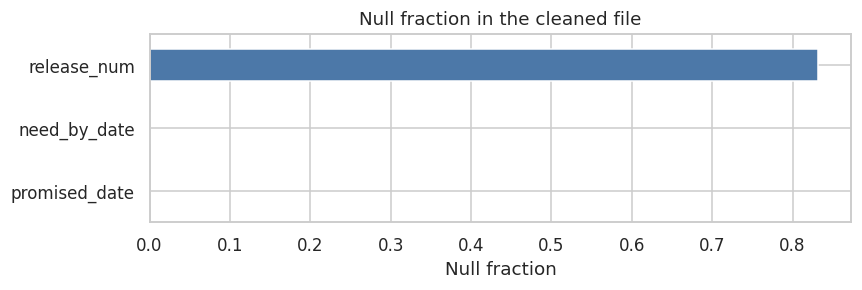

,rule,removed,remaining
0,Missing approval and creation date,0,21573
1,Lead time not computable,0,21573
2,Lead time <= 0 days,0,21573
3,Lead time > 365 days,0,21573
4,PO quantity <= 0,0,21573
5,Missing supplier or item,0,21573


After filters: 21,573 rows. Median lead time 125 days, mean 137.7, p90 275.
Saved /kaggle/working/output/figures/fig_02_lead_time_after_filters.png


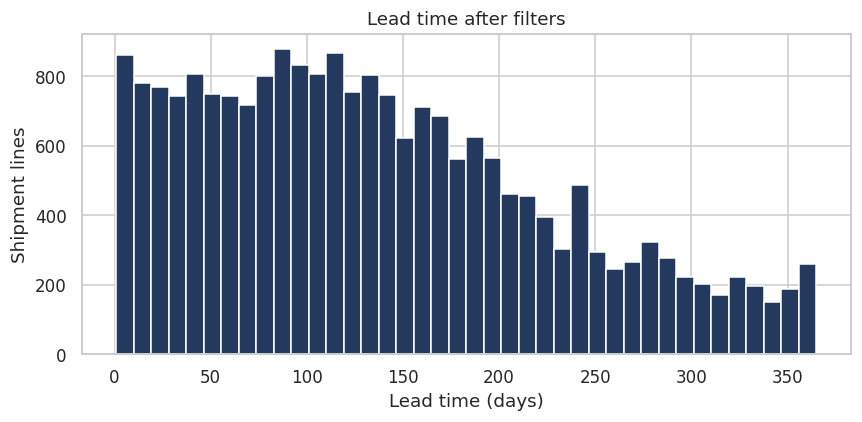

In [5]:
# cell:clean-run
cleaned = coerce_columns(cleaned)
if cleaned["line_location_id"].duplicated().any():
    print("Repeated line_location_id. Keeping the first positive-quantity receipt.")
    cleaned = aggregate_first_receipt(cleaned)
else:
    print(f"One row per line_location_id ({cleaned['line_location_id'].nunique():,} lines).")

plot_missing(cleaned, "Null fraction in the cleaned file")
cleaned, clean_log = clean_completed_lines(cleaned, LEAD_TIME_CAP_DAYS)
display(clean_log)
print(
    f"After filters: {len(cleaned):,} rows. Median lead time {cleaned['lead_time_days'].median():.0f} days, "
    f"mean {cleaned['lead_time_days'].mean():.1f}, "
    f"p90 {cleaned['lead_time_days'].quantile(0.9):.0f}."
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(cleaned["lead_time_days"], bins=40, color="#23395d", edgecolor="white")
ax.set_xlabel("Lead time (days)")
ax.set_ylabel("Shipment lines")
ax.set_title("Lead time after filters")
fig.tight_layout()
plt.show()


## Features known at order time

Used as-is: quantity, unit price, blanket flag, release flag, ship-to, organization, item status, approval month / quarter / weekday, requested days (`need_by_date - start`), promised days (`promised_date - start`).

Supplier, supplier site, and item are high cardinality, so they are not one-hot encoded. Each row gets the median lead time and the receipt count from receipts whose receipt date is strictly before that row's approval date:

- supplier
- supplier site
- item
- supplier + item

If a median is missing, fill item, then supplier, then the development-set median. Counts fill 0.

`supplier_item_hist_median_lt` is the baseline. The boosted model is useful only if its validation MAE and backtest MAE are lower than this baseline.


In [6]:
# cell:feature-fn
KEY_COLUMNS = ["supplier", "supplier_site_code", "item_number", "item_status", "ship_to_location_code", "organization_code"]


def fill_text_keys(frame):
    out = frame.copy()
    for column in KEY_COLUMNS:
        if column in out.columns:
            out[column] = out[column].astype("string").fillna("MISSING").astype(str)
    return out


def add_order_time_features(frame):
    out = fill_text_keys(frame)
    if "start_date" not in out.columns:
        out["start_date"] = out["approved_date"].fillna(out["creation_date"])
    out["start_date"] = pd.to_datetime(out["start_date"], errors="coerce")
    for column in ("need_by_date", "promised_date"):
        if column not in out.columns:
            out[column] = pd.NaT
        out[column] = pd.to_datetime(out[column], errors="coerce")
    out["is_blanket"] = out["type_lookup_code"].astype(str).str.upper().eq("BLANKET").astype(np.float32)
    out["has_release"] = out["release_num"].notna().astype(np.float32)
    out["approved_month"] = out["start_date"].dt.month.astype("float")
    out["approved_quarter"] = out["start_date"].dt.quarter.astype("float")
    out["approved_dow"] = out["start_date"].dt.dayofweek.astype("float")
    out["requested_lead_days"] = (out["need_by_date"].dt.normalize() - out["start_date"].dt.normalize()).dt.days.astype("float")
    out["promised_lead_days"] = (out["promised_date"].dt.normalize() - out["start_date"].dt.normalize()).dt.days.astype("float")
    out["po_quantity"] = pd.to_numeric(out["po_quantity"], errors="coerce")
    out["unit_price"] = pd.to_numeric(out["unit_price"], errors="coerce")
    return out


def attach_prior_stats(history, query, keys, value_col, hist_time, query_time):
    # Median and count of value_col using history rows strictly before each query time.
    keys = list(keys)
    empty_median = np.full(len(query), np.nan)
    empty_count = np.zeros(len(query))
    if len(query) == 0:
        return empty_median, empty_count
    hist = history.dropna(subset=keys + [hist_time, value_col]).copy()
    if hist.empty:
        return empty_median, empty_count
    hist = hist.sort_values(keys + [hist_time, "line_location_id"], kind="mergesort")
    grouped = hist.groupby(keys, sort=False)[value_col]
    hist["_med"] = grouped.transform(lambda series: series.expanding(min_periods=1).median())
    hist["_cnt"] = grouped.cumcount() + 1
    hist = hist.drop_duplicates(subset=keys + [hist_time], keep="last")
    right = hist[keys + [hist_time, "_med", "_cnt"]].copy()
    for key in keys:
        right[key] = right[key].astype(str)
    right = right.sort_values(hist_time, kind="mergesort")

    left = query.copy()
    left["_row"] = np.arange(len(left))
    for key in keys:
        left[key] = left[key].astype(str)
    if left[query_time].isna().any():
        raise ValueError(f"{query_time} has nulls. Cannot align prior receipts.")
    left = left.sort_values(query_time, kind="mergesort")
    merged = pd.merge_asof(
        left,
        right,
        left_on=query_time,
        right_on=hist_time,
        by=keys,
        direction="backward",
        allow_exact_matches=False,
    ).sort_values("_row")
    if not np.array_equal(merged["_row"].to_numpy(), np.arange(len(query))):
        raise RuntimeError("Prior-stat rows are not in the original order.")
    return merged["_med"].to_numpy(), merged["_cnt"].fillna(0).to_numpy()


def add_history_features(frame, history, query_time):
    out = frame.copy()
    for keys, median_name, count_name in HISTORY_SPECS:
        median, count = attach_prior_stats(
            history, out, keys, "lead_time_days", "transaction_date", query_time
        )
        out[median_name] = median
        out[count_name] = count
    return out


def cascade_history(frame, global_median):
    out = frame.copy()
    out["supplier_hist_median_lt"] = out["supplier_hist_median_lt"].fillna(global_median)
    out["supplier_site_hist_median_lt"] = out["supplier_site_hist_median_lt"].fillna(out["supplier_hist_median_lt"])
    out["item_hist_median_lt"] = out["item_hist_median_lt"].fillna(out["supplier_hist_median_lt"])
    out["supplier_item_hist_median_lt"] = (
        out["supplier_item_hist_median_lt"].fillna(out["item_hist_median_lt"]).fillna(out["supplier_hist_median_lt"])
    )
    for column in (
        "supplier_hist_count",
        "supplier_site_hist_count",
        "item_hist_count",
        "supplier_item_hist_count",
    ):
        out[column] = out[column].fillna(0)
    return out


def fit_category_levels(frame, columns, top_n):
    levels = {}
    for column in columns:
        values = frame[column].fillna("MISSING").astype(str)
        counts = values.value_counts().rename_axis("level").reset_index(name="n")
        counts = counts.sort_values(["n", "level"], ascending=[False, True])
        levels[column] = counts["level"].head(top_n).tolist()
    return levels


def encode_categories(frame, levels):
    pieces = []
    for column, keep in levels.items():
        values = frame[column].fillna("MISSING").astype(str).to_numpy()
        bucket = np.where(np.isin(values, keep), values, "__OTHER__")
        data = {f"{column}={level}": (bucket == level).astype(np.float32) for level in keep}
        data[f"{column}=__OTHER__"] = (bucket == "__OTHER__").astype(np.float32)
        pieces.append(pd.DataFrame(data, index=frame.index))
    if not pieces:
        return pd.DataFrame(index=frame.index)
    return pd.concat(pieces, axis=1)


def build_matrix(frame, spec):
    numeric = frame.loc[:, spec["numeric_features"]].apply(pd.to_numeric, errors="coerce")
    for column, median in spec["impute_medians"].items():
        if column in numeric.columns:
            numeric[column] = numeric[column].fillna(median)
    numeric = numeric.fillna(spec["global_median"])
    dummies = encode_categories(frame, spec["category_levels"])
    matrix = pd.concat([numeric.reset_index(drop=True), dummies.reset_index(drop=True)], axis=1)
    matrix = matrix.reindex(columns=spec["feature_columns"], fill_value=0.0)
    matrix = matrix.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0)
    matrix = matrix.astype(np.float32)
    matrix.columns = matrix.columns.astype(str)
    return matrix


## 2. Split

A random split leaks future receipts into training. The last 28 days are removed first. hgboost then splits only the older development set.

- Development: receipt date before the cutoff. Used for search, CV, and refit.
- Backtest: receipt inside the window and approval before the cutoff. Not passed to hgboost.
- Excluded: approved and received inside the window. Not used for training or this backtest.

On the development set, hgboost holds out 20% as validation, then splits the remaining 80% so the test set is 20% of the development set (`0.25 * 0.80`). Train is about 60%. Printed counts can differ by a few rows because of rounding.

- Train: fit each trial.
- Test: one fixed slice. All 500 trials are scored on it.
- Validation: scored once, after the model is chosen.


In [7]:
# cell:split-fn
from matplotlib.patches import FancyBboxPatch


def development_indices(n_rows, test_size, val_size, random_state):
    # Reproduce hgboost's validation split, then the adjusted test split.
    index = np.arange(n_rows)
    rest, validation = train_test_split(index, test_size=val_size, random_state=random_state, shuffle=True)
    adjusted_test = float(np.round((test_size * n_rows) / (n_rows - (val_size * n_rows)), 2))
    train, test = train_test_split(rest, test_size=adjusted_test, random_state=random_state, shuffle=True)
    return np.sort(train), np.sort(test), np.sort(validation), adjusted_test


def draw_split_diagram(counts):
    fig, ax = plt.subplots(figsize=(12.5, 9))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.axis("off")
    ax.set_title("Train, test, validation, and the 4-week holdout", fontsize=14, pad=8)

    def box(x, y, w, h, text, color):
        patch = FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.3,rounding_size=0.8",
            facecolor=color, edgecolor="#1f3b57", linewidth=1.1,
        )
        ax.add_patch(patch)
        ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=8.5, color="#102033")

    box(28, 88, 44, 9, f"Cleaned shipment lines\n{counts['cleaned']:,}", "#d6e2f0")
    box(2, 68, 30, 14, f"Development\nreceipt before {counts['cutoff']}\n{counts['development']:,}", "#d9ead3")
    box(35, 68, 30, 14, f"4-week backtest\napproved before cutoff, received in window\n{counts['backtest']:,}", "#ffe6c2")
    box(68, 68, 30, 14, f"Opened and received in window\nexcluded from train and backtest\n{counts['excluded']:,}", "#f4cccc")
    box(2, 46, 20, 14, f"Train ~60%\n{counts['train']:,}\nfit each trial", "#e7f5e1")
    box(24, 46, 20, 14, f"Test ~20%\n{counts['test']:,}\nfixed score for all trials", "#fff4cc")
    box(46, 46, 22, 14, f"Validation ~20%\n{counts['validation']:,}\nscored once after selection", "#f8d7da")
    box(2, 24, 66, 14, "Inner loop: Bayesian search. Fit on train, MAE on test.\nOuter loop: 5-fold CV on the top 10 test trials.", "#eef2f7")
    box(2, 6, 66, 12, "Pick the lowest 5-fold mean MAE, then refit on the development set.\nBacktest and open POs use that model. The backtest is not in the refit.", "#e3f2e6")
    arrow = dict(arrowstyle="->", color="#1f3b57", lw=1.1)
    ax.annotate("", xy=(17, 82), xytext=(42, 88), arrowprops=arrow)
    ax.annotate("", xy=(50, 82), xytext=(52, 88), arrowprops=arrow)
    ax.annotate("", xy=(80, 82), xytext=(62, 88), arrowprops=arrow)
    ax.annotate("", xy=(12, 60), xytext=(16, 68), arrowprops=arrow)
    ax.annotate("", xy=(34, 60), xytext=(20, 68), arrowprops=arrow)
    ax.annotate("", xy=(56, 60), xytext=(24, 68), arrowprops=arrow)
    ax.annotate("", xy=(34, 38), xytext=(34, 46), arrowprops=arrow)
    ax.annotate("", xy=(34, 18), xytext=(34, 24), arrowprops=arrow)
    fig.tight_layout()
    plt.show()


Latest receipt 2022-11-26. Backtest cutoff 2022-10-29 (receipt date >= cutoff, 28 days).
After the validation holdout, the test fraction of the remainder is 0.25 (~20% of the development set).
Development rows with no supplier-item history: 70.5%. Those rows fall back to the supplier or global median.


,cleaned,cutoff,development,backtest,excluded,train,test,validation
0,21573,2022-10-29,20777,702,94,12465,4156,4156


Saved /kaggle/working/output/figures/fig_03_train_test_validation_and_the_4_week_holdout.png


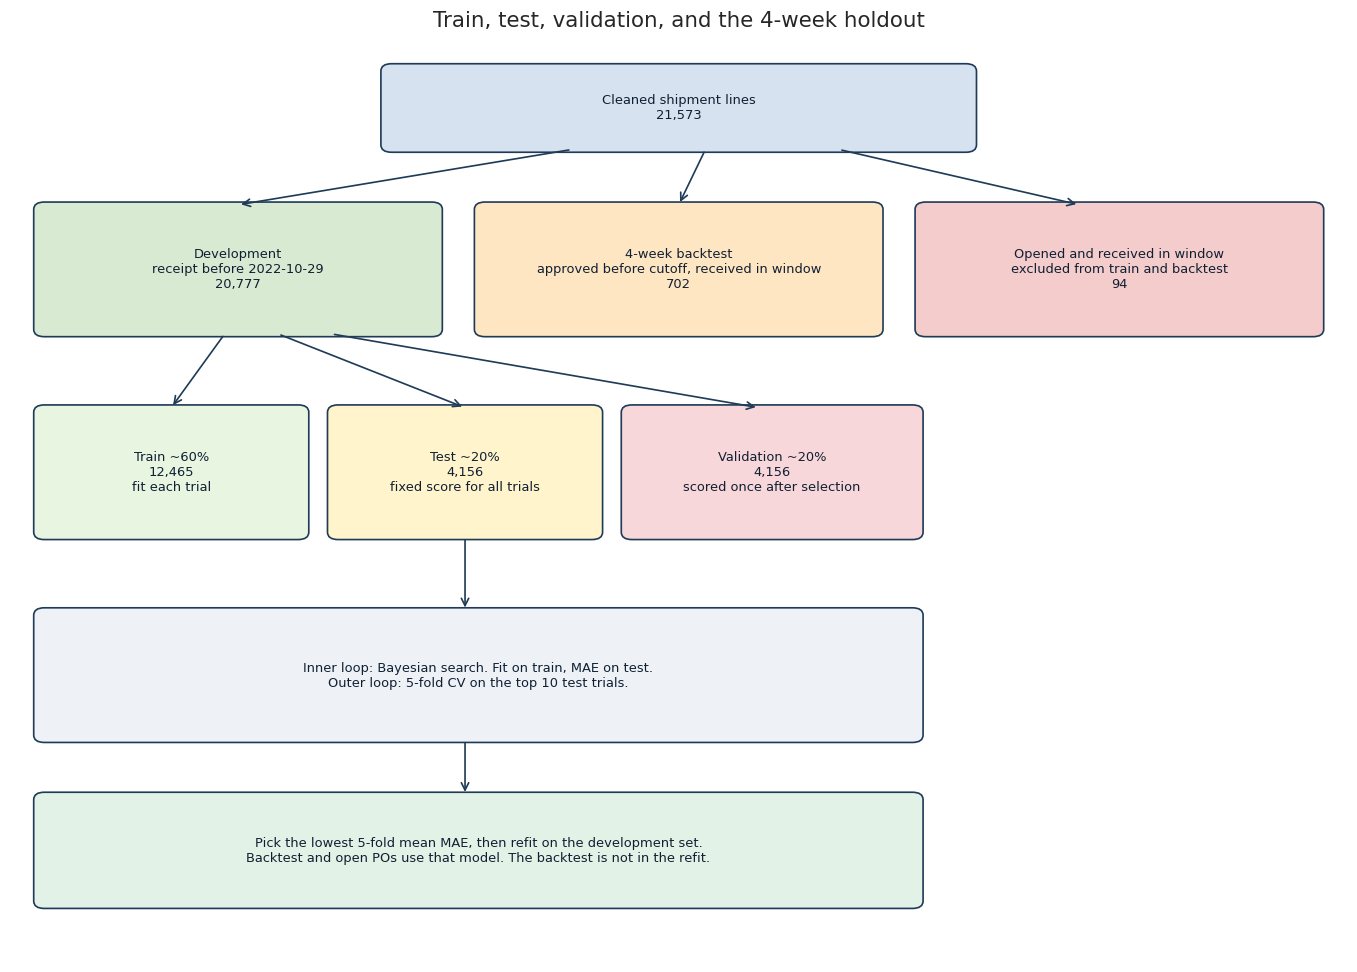

Feature matrix: (20777, 55) | target median: 125.0


In [8]:
# cell:split-run
featured = add_order_time_features(cleaned)
featured = add_history_features(featured, featured, query_time="start_date")

asof_day = featured["transaction_date"].max().normalize()
cutoff = asof_day - pd.Timedelta(days=BACKTEST_DAYS)
received_in_window = featured["transaction_date"] >= cutoff
approved_before_cutoff = featured["start_date"] < cutoff
backtest_mask = received_in_window & approved_before_cutoff
excluded_mask = received_in_window & ~approved_before_cutoff
development_mask = ~received_in_window

development = featured.loc[development_mask].sort_values("line_location_id", kind="mergesort").reset_index(drop=True)
backtest = featured.loc[backtest_mask].sort_values("line_location_id", kind="mergesort").reset_index(drop=True)
excluded = featured.loc[excluded_mask]
if len(development) < 50:
    raise RuntimeError(f"Development set has {len(development)} rows. Need at least 50 for a 20/20 split and 5-fold CV.")

global_median = float(development["lead_time_days"].median())
development = cascade_history(development, global_median)
backtest = cascade_history(backtest, global_median)

category_levels = fit_category_levels(development, CATEGORY_FEATURES, TOP_CATEGORY_LEVELS)
impute_medians = {}
for column in NUMERIC_FEATURES:
    median = float(pd.to_numeric(development[column], errors="coerce").median())
    impute_medians[column] = global_median if np.isnan(median) else median
dummy_columns = list(encode_categories(development, category_levels).columns)
spec = {
    "numeric_features": list(NUMERIC_FEATURES),
    "category_levels": category_levels,
    "impute_medians": impute_medians,
    "global_median": global_median,
    "feature_columns": list(NUMERIC_FEATURES) + dummy_columns,
    "cutoff": cutoff.isoformat(),
    "lead_time_cap_days": LEAD_TIME_CAP_DAYS,
}
with open(MODELS_DIR / "feature_spec.pkl", "wb") as handle:
    pickle.dump(spec, handle)

X_dev = build_matrix(development, spec)
y_dev = development["lead_time_days"].to_numpy(dtype=float)
train_idx, test_idx, val_idx, adjusted_test = development_indices(len(X_dev), TEST_SIZE, VAL_SIZE, RANDOM_STATE)
no_history = float((development["supplier_item_hist_count"] == 0).mean())

split_counts = {
    "cleaned": len(featured),
    "cutoff": cutoff.date().isoformat(),
    "development": len(development),
    "backtest": len(backtest),
    "excluded": len(excluded),
    "train": len(train_idx),
    "test": len(test_idx),
    "validation": len(val_idx),
}
print(f"Latest receipt {asof_day.date()}. Backtest cutoff {cutoff.date()} (receipt date >= cutoff, {BACKTEST_DAYS} days).")
print(f"After the validation holdout, the test fraction of the remainder is {adjusted_test:.2f} (~20% of the development set).")
print(f"Development rows with no supplier-item history: {no_history:.1%}. Those rows fall back to the supplier or global median.")
display(pd.DataFrame([split_counts]))
draw_split_diagram(split_counts)
if X_dev.isna().any().any():
    raise RuntimeError("Feature matrix still has nulls.")
print("Feature matrix:", X_dev.shape, "| target median:", np.median(y_dev))


### Split figure

Top box: cleaned shipment lines. First cut is by time: development, 4-week backtest, and lines both opened and received inside the window. Development is then train / test / validation. The lower boxes are the search and the refit, not more rows. The backtest is not in the refit.

If `supplier_item_hist_count = 0` is common, those rows use the supplier-level or global median, and the error on them is usually larger.


## 3. Metric

Search uses MAE (`eval_metric='mae'`), in days. Lower is better.

Also reported, not used for search:

- RMSE: penalizes large misses more than MAE.
- R²: 1 is a perfect fit, 0 matches predicting the mean.
- MedianAE: less sensitive to a few very slow orders.
- Within 7 days: share of rows with absolute error `<= 7`.

Pick the algorithm with the lowest 5-fold mean MAE, then the smaller fold std. Validation MAE is the check that was not used to choose trials. A test MAE much lower than the validation MAE means that trial fit the fixed test slice.


In [9]:
# cell:metrics
def regression_metrics(y_true, y_pred):
    actual = np.asarray(y_true, dtype=float).reshape(-1)
    pred = np.asarray(y_pred, dtype=float).reshape(-1)
    error = np.abs(actual - pred)
    return {
        "MAE": float(mean_absolute_error(actual, pred)),
        "RMSE": float(np.sqrt(mean_squared_error(actual, pred))),
        "R2": float(r2_score(actual, pred)),
        "MedianAE": float(np.median(error)),
        "Within_7_days": float(np.mean(error <= WITHIN_DAYS)),
    }


def metrics_frame(named_predictions, y_true):
    rows = []
    for name, pred in named_predictions.items():
        row = {"model": name}
        row.update(regression_metrics(y_true, pred))
        rows.append(row)
    return pd.DataFrame(rows).set_index("model")


## 4. Nested CV on GPU

Each algorithm gets its own `hgboost` object. `random_state=42` keeps the same train, test, and validation rows.

- Inner loop: Hyperopt TPE, `MAX_EVAL` trials. Every trial fits on the training rows and scores MAE on the same test rows.
- Outer loop: 5-fold CV on the top `TOP_CV_EVALS` trials. Keep the trial with the lowest mean MAE.

XGBoost searches `learning_rate`, `max_depth`, `min_child_weight`, `gamma`, `reg_lambda`, `subsample`, `n_estimators`. LightGBM searches learning rate, depth, min child weight, subsample, and `n_estimators`. CatBoost searches learning rate, depth, and `n_estimators`.

CatBoost GPU does not support `colsample_bylevel` (`rsm`) or the default Bayesian bootstrap, so those stay out of the GPU search. Bootstrap is Poisson. hgboost also passes two eval sets, which CatBoost GPU rejects, so CatBoost trials early-stop on the test slice only. The Hyperopt loss is still MAE on that same test slice.

hgboost's own `gpu=True` flag does not turn CatBoost onto the GPU, and its XGBoost GPU settings use the removed `predictor='gpu_predictor'`. This cell passes the current device arguments instead. `n_jobs=1` because the trials are sequential and the trees run on the GPU.

Each fit still receives its own feature-matrix copy: hgboost resets the frame index in place, and the next algorithm needs the original matrix.

Per-tree logs go to `/kaggle/working/models/search_stdout.log`. The cell stays quiet until the trials finish, then the 5-fold bar starts.


In [10]:
# cell:train
import inspect
import sys

try:
    from hgboost import hgboost
except ImportError as exc:
    raise ImportError("hgboost is not installed. Run the install cell with Internet on.") from exc

try:
    import hgboost.hgboost as hgb_mod
except ImportError:
    hgb_mod = sys.modules.get(getattr(hgboost, "__module__", ""), None)

# hgboost/__init__.py does `from hgboost.hgboost import hgboost`, so the package
# attribute is the class and shadows the submodule. `import hgboost.hgboost as hgb_mod`
# then attribute-looks-up that name and binds the class. The class has no `.hgboost`.
if inspect.ismodule(hgb_mod):
    candidate = getattr(hgb_mod, "hgboost", None)
    HGBClass = candidate if inspect.isclass(candidate) else hgboost
elif inspect.isclass(hgb_mod) or inspect.isclass(hgboost):
    HGBClass = hgb_mod if inspect.isclass(hgb_mod) else hgboost
    hgb_mod = sys.modules[HGBClass.__module__]
else:
    raise TypeError(f"Could not resolve hgboost class or module (got {type(hgb_mod)!r})")

if not inspect.isclass(HGBClass) or not hasattr(HGBClass, "_train_model"):
    raise AttributeError("hgboost class has no _train_model to patch")
if not inspect.ismodule(hgb_mod) or not hasattr(hgb_mod, "_get_params"):
    raise AttributeError("hgboost module has no _get_params")

for logger_name in ("hgboost", "hgboost.hgboost"):
    logging.getLogger(logger_name).setLevel(logging.INFO)

_orig_train_model = HGBClass._train_model


def _train_model_gpu_catboost(self, model, space):
    # CatBoost GPU rejects two eval sets. Early stopping still watches the fixed test slice.
    gpu_catboost = (
        type(model).__name__.startswith("CatBoost")
        and space.get("model_params", {}).get("task_type") == "GPU"
    )
    if not gpu_catboost:
        return _orig_train_model(self, model, space)
    fit_kwargs = {key: value for key, value in space["fit_params"].items() if not str(key).startswith("_")}
    model.fit(self.X_train, self.y_train, eval_set=(self.X_test, self.y_test), **fit_kwargs)
    return self._eval(self.X_test, self.y_test, model)


HGBClass._train_model = _train_model_gpu_catboost


def _probe_xgboost_gpu():
    import xgboost as xgb

    X = np.random.rand(64, 4)
    y = np.random.rand(64)
    candidates = (
        {"tree_method": "hist", "device": "cuda"},
        {"tree_method": "gpu_hist"},
    )
    errors = []
    for params in candidates:
        try:
            xgb.XGBRegressor(n_estimators=1, n_jobs=1, verbosity=0, **params).fit(X, y)
            print("XGBoost GPU params:", params)
            return params
        except Exception as exc:
            errors.append(f"{params}: {type(exc).__name__}: {exc}")
    raise RuntimeError(
        "XGBoost cannot see the GPU. Set Accelerator to GPU and rerun.\n" + "\n".join(errors)
    )


def _probe_lightgbm_device():
    import lightgbm as lgb

    X = np.random.rand(64, 4)
    y = np.random.rand(64)
    candidates = (
        {"device_type": "cuda", "gpu_device_id": 0},
        {"device_type": "gpu", "gpu_device_id": 0},
    )
    errors = []
    for params in candidates:
        try:
            lgb.LGBMRegressor(n_estimators=1, verbosity=-1, **params).fit(X, y)
            print("LightGBM GPU params:", params)
            return params
        except Exception as exc:
            errors.append(f"{params}: {type(exc).__name__}: {exc}")
    print("LightGBM GPU is not in this build. Trials stay on CPU.")
    for line in errors:
        print(line)
    return {"device_type": "cpu"}


def _probe_catboost_gpu():
    import catboost as ctb

    X = np.random.rand(64, 4)
    y = np.random.rand(64)
    model = ctb.CatBoostRegressor(
        iterations=2,
        depth=2,
        task_type="GPU",
        devices="0",
        bootstrap_type="Poisson",
        verbose=0,
        allow_writing_files=False,
    )
    try:
        model.fit(X, y, eval_set=(X, y))
    except Exception as exc:
        raise RuntimeError(
            "CatBoost GPU failed. Set Accelerator to GPU and rerun."
        ) from exc
    print("CatBoost task_type: GPU")


XGB_GPU_PARAMS = _probe_xgboost_gpu()
LGB_DEVICE = _probe_lightgbm_device()
_probe_catboost_gpu()


def gpu_search_space(name):
    method = {"xgboost": "xgb_reg", "lightgbm": "lgb_reg", "catboost": "ctb_reg"}[name]
    space = hgb_mod._get_params(method, eval_metric="mae", gpu=False, early_stopping_rounds=25)
    model_params = space["model_params"]
    if method == "xgb_reg":
        model_params.pop("predictor", None)
        model_params.pop("gpu_id", None)
        model_params.update(XGB_GPU_PARAMS)
    elif method == "lgb_reg":
        for key in ("device", "device_type", "gpu_platform_id", "gpu_device_id"):
            model_params.pop(key, None)
        model_params.update(LGB_DEVICE)
    elif method == "ctb_reg":
        model_params["task_type"] = "GPU"
        model_params["devices"] = "0"
        model_params["bootstrap_type"] = "Poisson"
        model_params.pop("colsample_bylevel", None)
    return space


def training_stamp(feature_spec, n_rows):
    return {
        "max_eval": MAX_EVAL,
        "fast_dev": FAST_DEV,
        "random_state": RANDOM_STATE,
        "test_size": TEST_SIZE,
        "val_size": VAL_SIZE,
        "cv": CV_FOLDS,
        "top_cv_evals": TOP_CV_EVALS,
        "n_rows": int(n_rows),
        "features": list(feature_spec["feature_columns"]),
        "xgb_gpu": dict(XGB_GPU_PARAMS),
        "lgb_device": dict(LGB_DEVICE),
        "catboost_task_type": "GPU",
    }


def summary_flag(summary, column):
    if column not in summary.columns:
        raise KeyError(f"hgboost summary has no column {column}")
    return summary.loc[summary[column].fillna(False) == True]


def show_top10(name, summary):
    table = summary.copy()
    if "default_params" in table.columns:
        table = table.loc[table["default_params"].fillna(False) != True]
    ranked = table.dropna(subset=["loss_mean"]).sort_values(["loss_mean", "loss_std"])
    columns = ["loss", "loss_mean", "loss_std", "best", "best_cv", "learning_rate", "max_depth",
               "min_child_weight", "n_estimators", "subsample", "gamma", "reg_lambda", "colsample_bylevel"]
    columns = [column for column in columns if column in ranked.columns]
    print(f"{name}: top {min(10, len(ranked))} trials by 5-fold mean MAE")
    display(ranked[columns].head(10))


def new_hgboost():
    # gpu=False here: the library flag does not enable CatBoost GPU. Device args are in gpu_search_space.
    return hgboost(
        max_eval=MAX_EVAL,
        cv=CV_FOLDS,
        test_size=TEST_SIZE,
        val_size=VAL_SIZE,
        top_cv_evals=TOP_CV_EVALS,
        random_state=RANDOM_STATE,
        n_jobs=1,
        gpu=False,
        verbose="info",
    )


stamp = training_stamp(spec, len(X_dev))
stamp_path = MODELS_DIR / "training_stamp.pkl"
stamp_matches = False
if stamp_path.exists() and not FORCE_RETRAIN:
    try:
        with open(stamp_path, "rb") as handle:
            stamp_matches = pickle.load(handle) == stamp
    except Exception:
        stamp_matches = False


class _QuietStdout:
    # XGBoost prints every tree to stdout. Keep the notebook readable and store that text in a log.
    def __enter__(self):
        import sys
        self._stdout = sys.stdout
        self._handle = open(MODELS_DIR / "search_stdout.log", "a", encoding="utf-8")
        sys.stdout = self._handle
        return self

    def __exit__(self, *args):
        import sys
        sys.stdout = self._stdout
        self._handle.close()


trained = {}
for name, method_name in ALGORITHMS.items():
    path = MODELS_DIR / f"{name}.pkl"
    model = new_hgboost()
    loaded = False
    if path.exists() and stamp_matches and not FORCE_RETRAIN:
        print(f"Loading saved {name}. Retrain only if the config or development set changed.")
        try:
            model.load(str(path))
            loaded = getattr(model, "model", None) is not None and model.results is not None
        except Exception as exc:
            print(f"Could not load {name}. Retraining: {exc}")
            model = new_hgboost()
    if not loaded:
        print(f"Training {name} on GPU settings above. Up to {MAX_EVAL} trials.")
        print("Per-tree log:", MODELS_DIR / "search_stdout.log")
        with _QuietStdout():
            # Copy X because hgboost resets the index in place. y is not modified.
            getattr(model, method_name)(
                X_dev.copy(),
                y_dev,
                eval_metric="mae",
                params=gpu_search_space(name),
            )
        model.save(str(path), overwrite=True)
    if hasattr(model, "y_val"):
        if not np.allclose(np.sort(model.y_val), np.sort(y_dev[val_idx])):
            raise RuntimeError(f"{name} validation labels do not match the reconstructed split.")
    trained[name] = model
    show_top10(name, model.results["summary"])

if not stamp_matches or FORCE_RETRAIN:
    with open(stamp_path, "wb") as handle:
        pickle.dump(stamp, handle)
print("All three algorithms are ready.")
print("Models:", MODELS_DIR)


XGBoost GPU params: {'tree_method': 'hist', 'device': 'cuda'}


[LightGBM] [Fatal] CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


LightGBM GPU params: {'device_type': 'gpu', 'gpu_device_id': 0}


2026-10-04 01:37:13,137 Collecting xgb_reg parameters.
2026-10-04 01:37:13,139 Start hgboost regression.
2026-10-04 01:37:13,143 method: xgb_reg
2026-10-04 01:37:13,144 eval_metric: mae
2026-10-04 01:37:13,144 larger_is_better: False
2026-10-04 01:37:13,146 *****************************************************************************************
2026-10-04 01:37:13,147 Total dataset: (20777, 55) 
2026-10-04 01:37:13,155 Validation set: (4156, 55) 
2026-10-04 01:37:13,164 Test-set: (4156, 55) 
2026-10-04 01:37:13,165 Train-set: (12465, 55) 
2026-10-04 01:37:13,168 *****************************************************************************************
2026-10-04 01:37:13,173 Searching across hyperparameter space for best performing parameters using maximum evaluations: 500
2026-10-04 01:37:13,202 build_posterior_wrapper took 0.006275 seconds
2026-10-04 01:37:13,203 TPE using 0 trials


CatBoost task_type: GPU
Training xgboost on GPU settings above. Up to 500 trials.
Per-tree log: /kaggle/working/models/search_stdout.log


...

Training catboost on GPU settings above. Up to 500 trials.
Per-tree log: /kaggle/working/models/search_stdout.log


2026-10-04 02:10:12,587 build_posterior_wrapper took 0.004203 seconds
2026-10-04 02:10:12,588 TPE using 1/1 trials with best loss 27.106527
2026-10-04 02:10:13,188 build_posterior_wrapper took 0.002367 seconds
2026-10-04 02:10:13,189 TPE using 2/2 trials with best loss 27.106527
2026-10-04 02:10:15,351 build_posterior_wrapper took 0.003756 seconds
2026-10-04 02:10:15,351 TPE using 3/3 trials with best loss 26.233480
2026-10-04 02:10:17,575 build_posterior_wrapper took 0.002353 seconds
2026-10-04 02:10:17,576 TPE using 4/4 trials with best loss 25.503396
2026-10-04 02:10:20,144 build_posterior_wrapper took 0.003559 seconds
2026-10-04 02:10:20,145 TPE using 5/5 trials with best loss 25.503396
2026-10-04 02:10:20,809 build_posterior_wrapper took 0.002256 seconds
2026-10-04 02:10:20,810 TPE using 6/6 trials with best loss 25.503396
2026-10-04 02:10:21,582 build_posterior_wrapper took 0.002389 seconds
2026-10-04 02:10:21,583 TPE using 7/7 trials with best loss 25.503396
2026-10-04 02:10:26,

catboost: top 10 trials by 5-fold mean MAE


,loss,loss_mean,loss_std,best,best_cv,learning_rate,max_depth,n_estimators
446,24.957885,25.301168,0.361225,0.0,1.0,0.15,None,None
409,24.957885,25.402456,0.263189,0.0,0.0,0.15,None,None
492,24.957885,25.445365,0.437791,0.0,0.0,0.15,None,None
413,24.957885,25.452296,0.337406,0.0,0.0,0.15,None,None
445,24.957885,25.455974,0.482970,0.0,0.0,0.15,None,None
433,24.957885,25.515011,0.281050,0.0,0.0,0.15,None,None
497,24.957885,25.521015,0.300867,0.0,0.0,0.15,None,None
491,24.957885,25.557583,0.320610,0.0,0.0,0.15,None,None
408,24.957885,25.607191,0.277124,0.0,0.0,0.15,None,None
434,24.957885,25.710643,0.570849,0.0,0.0,0.15,None,None


All three algorithms are ready.
Models: /kaggle/working/models


### Top 10 parameter sets

`loss` is test MAE. `loss_mean` and `loss_std` are the 5-fold mean and std. `best` is the best test MAE among the trials. `best_cv` is the best 5-fold mean among the top 10. The kept parameters are `best_cv`, not `best`.

Low `loss` with high `loss_mean` or `loss_std` means the trial won one split and failed the others.


## 5. Select the model

Rank by `best_cv` mean MAE, then by fold std. The validation set is not used for this rank.

- `search_test_mae`: best MAE on the fixed test slice.
- `validation_mae_before_refit`: validation MAE before the refit on the full development set.
- `default_validation_mae`: same validation rows, library default parameters.

The comparison table is `/kaggle/working/output/model_comparison.csv`. The selected name is `/kaggle/working/output/winner.txt`.


,algorithm,cv_mean_mae,cv_std_mae,search_test_mae,validation_mae_before_refit,default_validation_mae
0,xgboost,24.005,0.366,24.098,23.564,26.159
1,catboost,25.301,0.361,24.958,25.013,25.834
2,lightgbm,26.144,0.461,25.714,25.929,26.350


Selected: xgboost. 5-fold mean MAE 24.005 days.
Saved /kaggle/working/output/figures/fig_04_algorithm_comparison.png


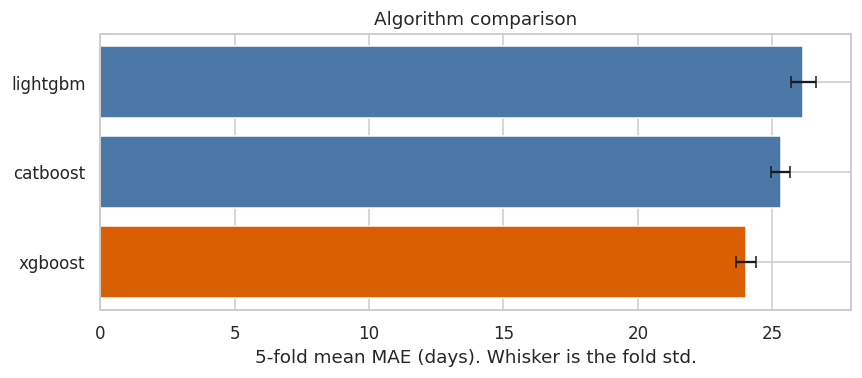

In [11]:
# cell:rank
ranking_rows = []
for name, model in trained.items():
    summary = model.results["summary"]
    best_search = summary_flag(summary, "best").iloc[0]
    best_cv = summary_flag(summary, "best_cv").iloc[0]
    default_rows = summary_flag(summary, "default_params") if "default_params" in summary.columns else pd.DataFrame()
    default_mae = float(default_rows.iloc[0]["loss_validation"]) if len(default_rows) and "loss_validation" in default_rows else np.nan
    ranking_rows.append({
        "algorithm": name,
        "cv_mean_mae": float(best_cv["loss_mean"]),
        "cv_std_mae": float(best_cv["loss_std"]),
        "search_test_mae": float(best_search["loss"]),
        "validation_mae_before_refit": float(best_cv["loss_validation"]),
        "default_validation_mae": default_mae,
    })

ranking = pd.DataFrame(ranking_rows).sort_values(["cv_mean_mae", "cv_std_mae"]).reset_index(drop=True)
ranking.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False, encoding="utf-8-sig")
winner_name = ranking.iloc[0]["algorithm"]
winner = trained[winner_name]
(OUTPUT_DIR / "winner.txt").write_text(winner_name, encoding="utf-8")
display(ranking.style.format("{:.3f}", subset=ranking.columns.drop("algorithm")))
print(f"Selected: {winner_name}. 5-fold mean MAE {ranking.iloc[0]['cv_mean_mae']:.3f} days.")

fig, ax = plt.subplots(figsize=(8, 3.6))
plot_rank = ranking.sort_values("cv_mean_mae", ascending=True)
colors = ["#d95f02" if name == winner_name else "#4c78a8" for name in plot_rank["algorithm"]]
ax.barh(plot_rank["algorithm"], plot_rank["cv_mean_mae"], xerr=plot_rank["cv_std_mae"], color=colors, capsize=4)
ax.set_xlabel("5-fold mean MAE (days). Whisker is the fold std.")
ax.set_title("Algorithm comparison")
fig.tight_layout()
plt.show()


### Algorithm comparison

Bar length is 5-fold mean MAE in days. The whisker is the fold std. Shorter is better. Orange is the selected algorithm. If the shortest bar has a much wider whisker than the next bar, the std column in the table is the tie-break already applied.


## 6. Validation set

`validation_mae_before_refit` is scored before the refit, so those rows were not used to grow trees. RMSE, R², MedianAE, and the 7-day rate are not stored at that point. When the fit function returns, hgboost has already refit on the whole development set, including the validation rows. Scores from that refit model on the validation rows are slightly low. Use the 4-week backtest for the untouched numbers.

The baseline is `supplier_item_hist_median_lt` on the same validation rows.


2026-10-04 02:31:30,135 No y_proba for xgb_reg


Validation MAE before refit: 23.564 days. Default-parameter validation MAE: 26.159. Best fixed-test MAE during search: 24.098.
Validation MAE is close to the fixed-test MAE.


,MAE,RMSE,R2,MedianAE,Within_7_days
model,,,,,
winner_after_refit,4.209,8.601,0.991,1.693,0.840
history_median_baseline,71.367,93.913,-0.101,55.000,0.088


winner_after_refit is scored after the refit, so it is slightly optimistic. Do not replace the pre-refit MAE with it.
Saved /kaggle/working/output/figures/fig_05_validation_model_vs_historical_median.png


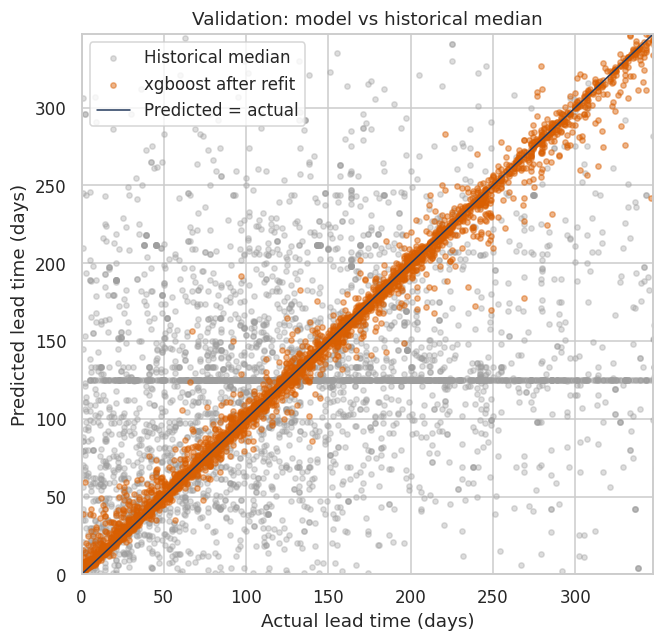

In [12]:
# cell:validation
winner_row = ranking.loc[ranking["algorithm"] == winner_name].iloc[0]
val_actual = y_dev[val_idx]
val_matrix = X_dev.iloc[val_idx]
val_pred, _ = winner.predict(val_matrix)
val_pred = np.asarray(val_pred, dtype=float).reshape(-1)
baseline_pred = val_matrix["supplier_item_hist_median_lt"].to_numpy(dtype=float)
val_metrics = metrics_frame({"winner_after_refit": val_pred, "history_median_baseline": baseline_pred}, val_actual)
print(
    f"Validation MAE before refit: {winner_row['validation_mae_before_refit']:.3f} days. "
    f"Default-parameter validation MAE: {winner_row['default_validation_mae']:.3f}. "
    f"Best fixed-test MAE during search: {winner_row['search_test_mae']:.3f}."
)
if winner_row["validation_mae_before_refit"] > winner_row["search_test_mae"] * 1.15:
    print("Validation MAE is more than 15% above the fixed-test MAE. That trial was optimistic on the test slice. Use the 5-fold mean and the backtest.")
else:
    print("Validation MAE is close to the fixed-test MAE.")
display(val_metrics.style.format("{:.3f}"))
print("winner_after_refit is scored after the refit, so it is slightly optimistic. Do not replace the pre-refit MAE with it.")

fig, ax = plt.subplots(figsize=(6.2, 6))
ax.scatter(val_actual, baseline_pred, s=12, alpha=0.35, label="Historical median", color="#9e9e9e")
ax.scatter(val_actual, val_pred, s=12, alpha=0.45, label=f"{winner_name} after refit", color="#d95f02")
upper = float(np.nanpercentile(np.r_[val_actual, val_pred, baseline_pred], 99))
ax.plot([0, upper], [0, upper], color="#23395d", lw=1, label="Predicted = actual")
ax.set_xlim(0, upper)
ax.set_ylim(0, upper)
ax.set_xlabel("Actual lead time (days)")
ax.set_ylabel("Predicted lead time (days)")
ax.set_title("Validation: model vs historical median")
ax.legend()
fig.tight_layout()
plt.show()


### Validation scatter

On the diagonal, prediction equals actual. Above the line, the predicted lead time is too long. Gray is the historical median. Orange is the refit model. The number to quote is the printed pre-refit validation MAE, not this scatter.


## 7. Refit

No extra `fit` call. After choosing parameters, hgboost refits on the development matrix it was given, including its validation rows. Backtest rows are not in that matrix.

Models: `/kaggle/working/models/xgboost.pkl`, `lightgbm.pkl`, `catboost.pkl`. Later cells call `winner.predict`.


In [13]:
# cell:refit
print(f"{winner_name} was refit on {len(X_dev):,} development rows and saved to {MODELS_DIR / (winner_name + '.pkl')}.")
print("Features:", len(spec["feature_columns"]))
print("Backtest rows (not in the refit):", f"{len(backtest):,}")
print("best_cv parameters:")
cv_row = summary_flag(winner.results["summary"], "best_cv").iloc[0]
param_names = [name for name in (
    "learning_rate", "max_depth", "min_child_weight", "gamma", "reg_lambda",
    "subsample", "n_estimators", "colsample_bylevel",
) if name in cv_row.index]
display(cv_row[param_names].to_frame("value"))


xgboost was refit on 20,777 development rows and saved to /kaggle/working/models/xgboost.pkl.
Features: 55
Backtest rows (not in the refit): 702
best_cv parameters:


,value
learning_rate,0.05
max_depth,26
min_child_weight,2
gamma,0.25
reg_lambda,10.0
subsample,0.841334
n_estimators,180


## 8. Search plots

For each algorithm:

- `.plot()`: one point per trial, y = test MAE. Green dashed line: best test MAE. Red dotted line: best 5-fold mean. Squares: top 10 sent to CV. The lower panel, if it draws, is train and test error by tree.
- `.plot_params()`: values tried for each hyperparameter.
- `.plot_cv()`: predicted vs actual on the five resplits.
- `.plot_validation()`: validation scatter. For regression the title often omits MAE. Use the MAE from step 6.

The extra curve uses the same `summary` table: x = trial id, y = test MAE. Figures are also written to `/kaggle/working/output/figures`.


### Reading the search plots

A falling curve means later trials reduced test MAE. A flat curve means a larger `MAX_EVAL` is unlikely to help. A wide gap between the green line and the red line means the test-set winner did not survive CV.

In `.plot_params()`, a peak in a narrow range means the search settled there. A flat density means that parameter did not change MAE.

In `.plot_cv()`, folds should sit on the diagonal. One fold off the line increases `loss_std`.


xgboost
Saved /kaggle/working/output/figures/fig_06_xgb_reg_5_fold_cv_mean_mae_24.png


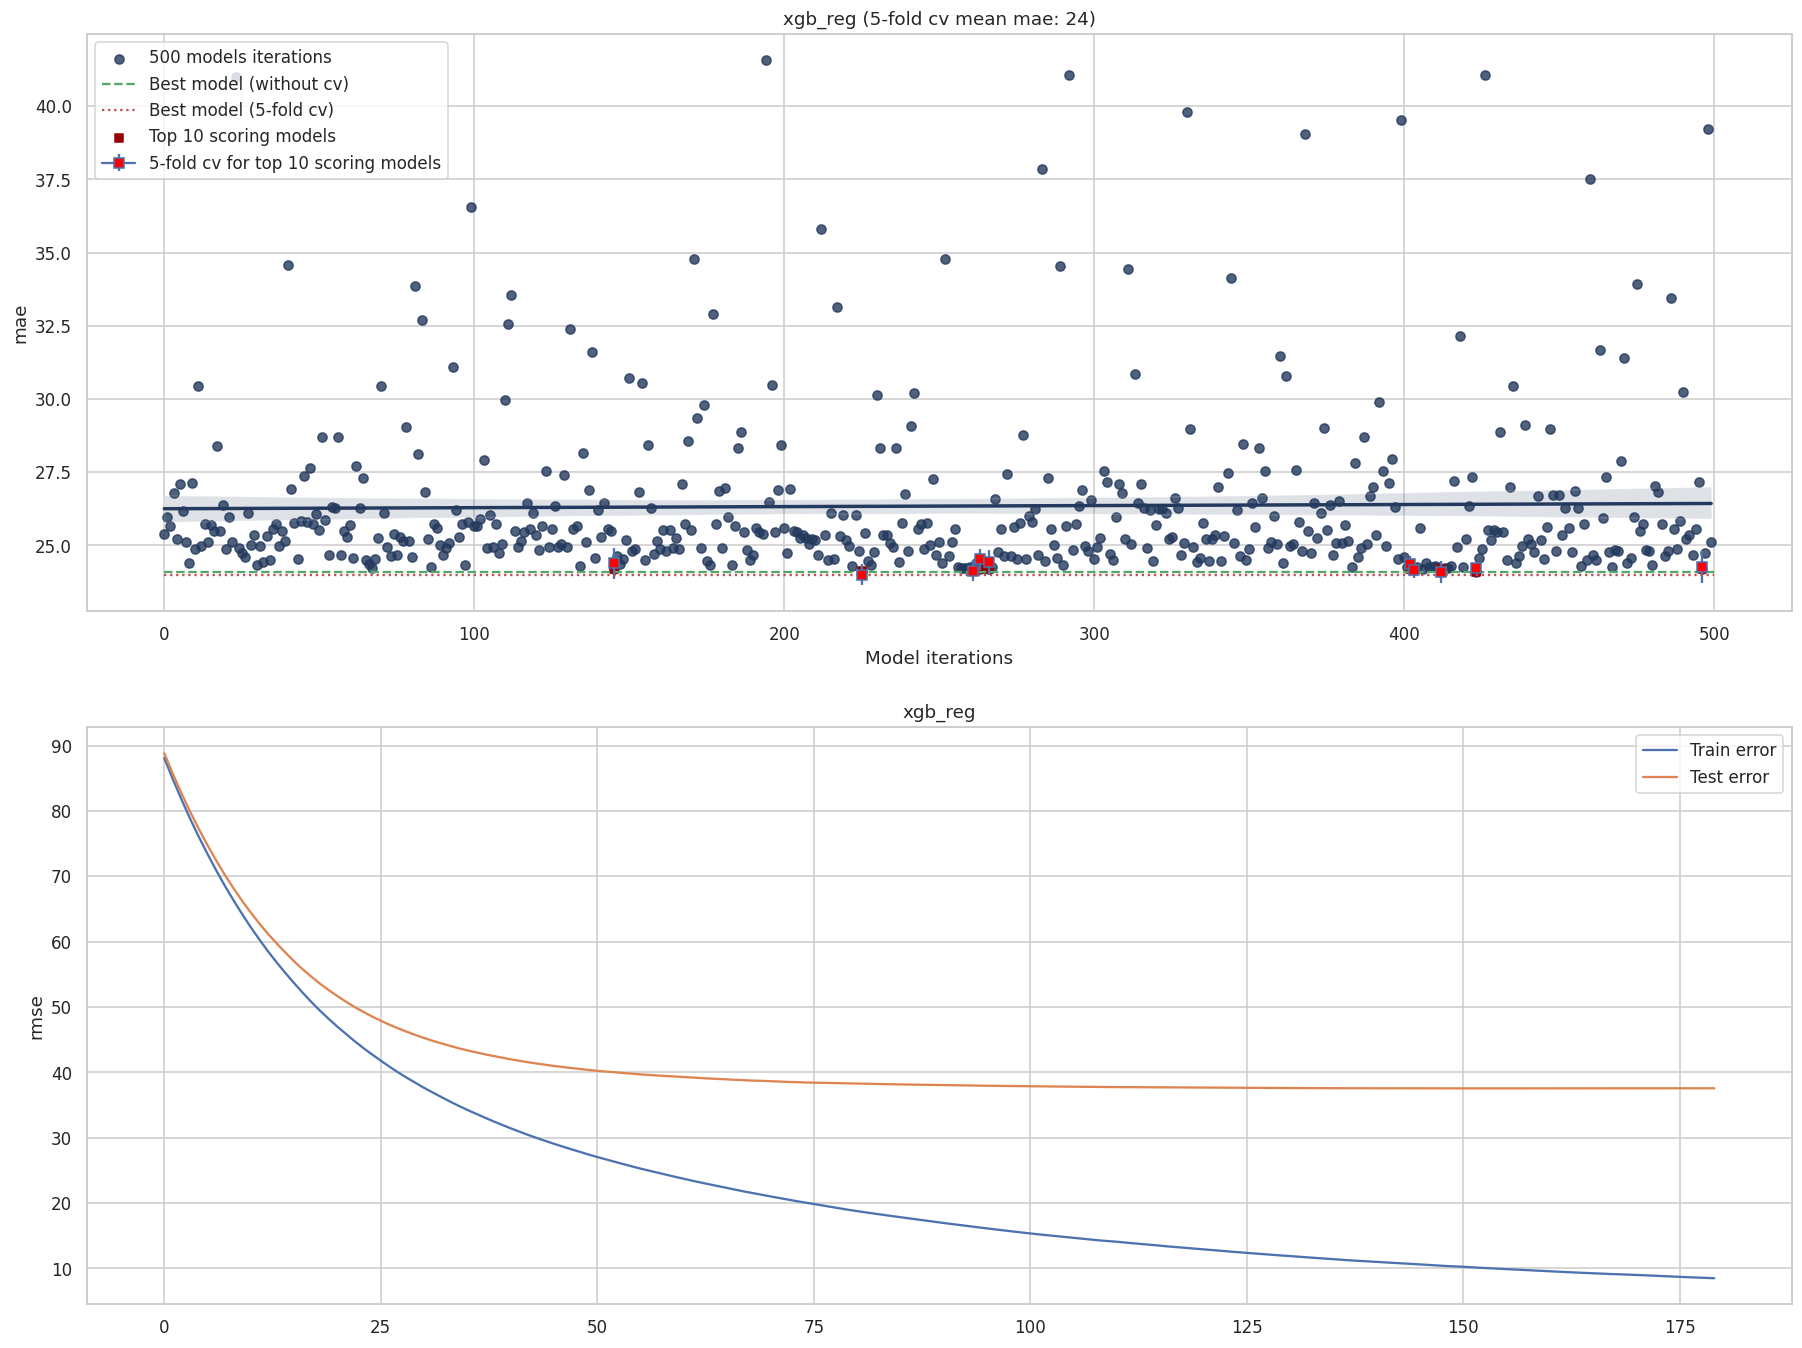

[04-10-2026 02:31:33] [colourmap.colourmap] [WARNING] Colormap [Set2] can not create [11] unique colors! Available unique colors: [8].
2026-10-04 02:31:39,352 Scatter plot failed [tid]: arg must be a list, tuple, 1-d array, or Series


Saved /kaggle/working/output/figures/fig_07_gamma.png


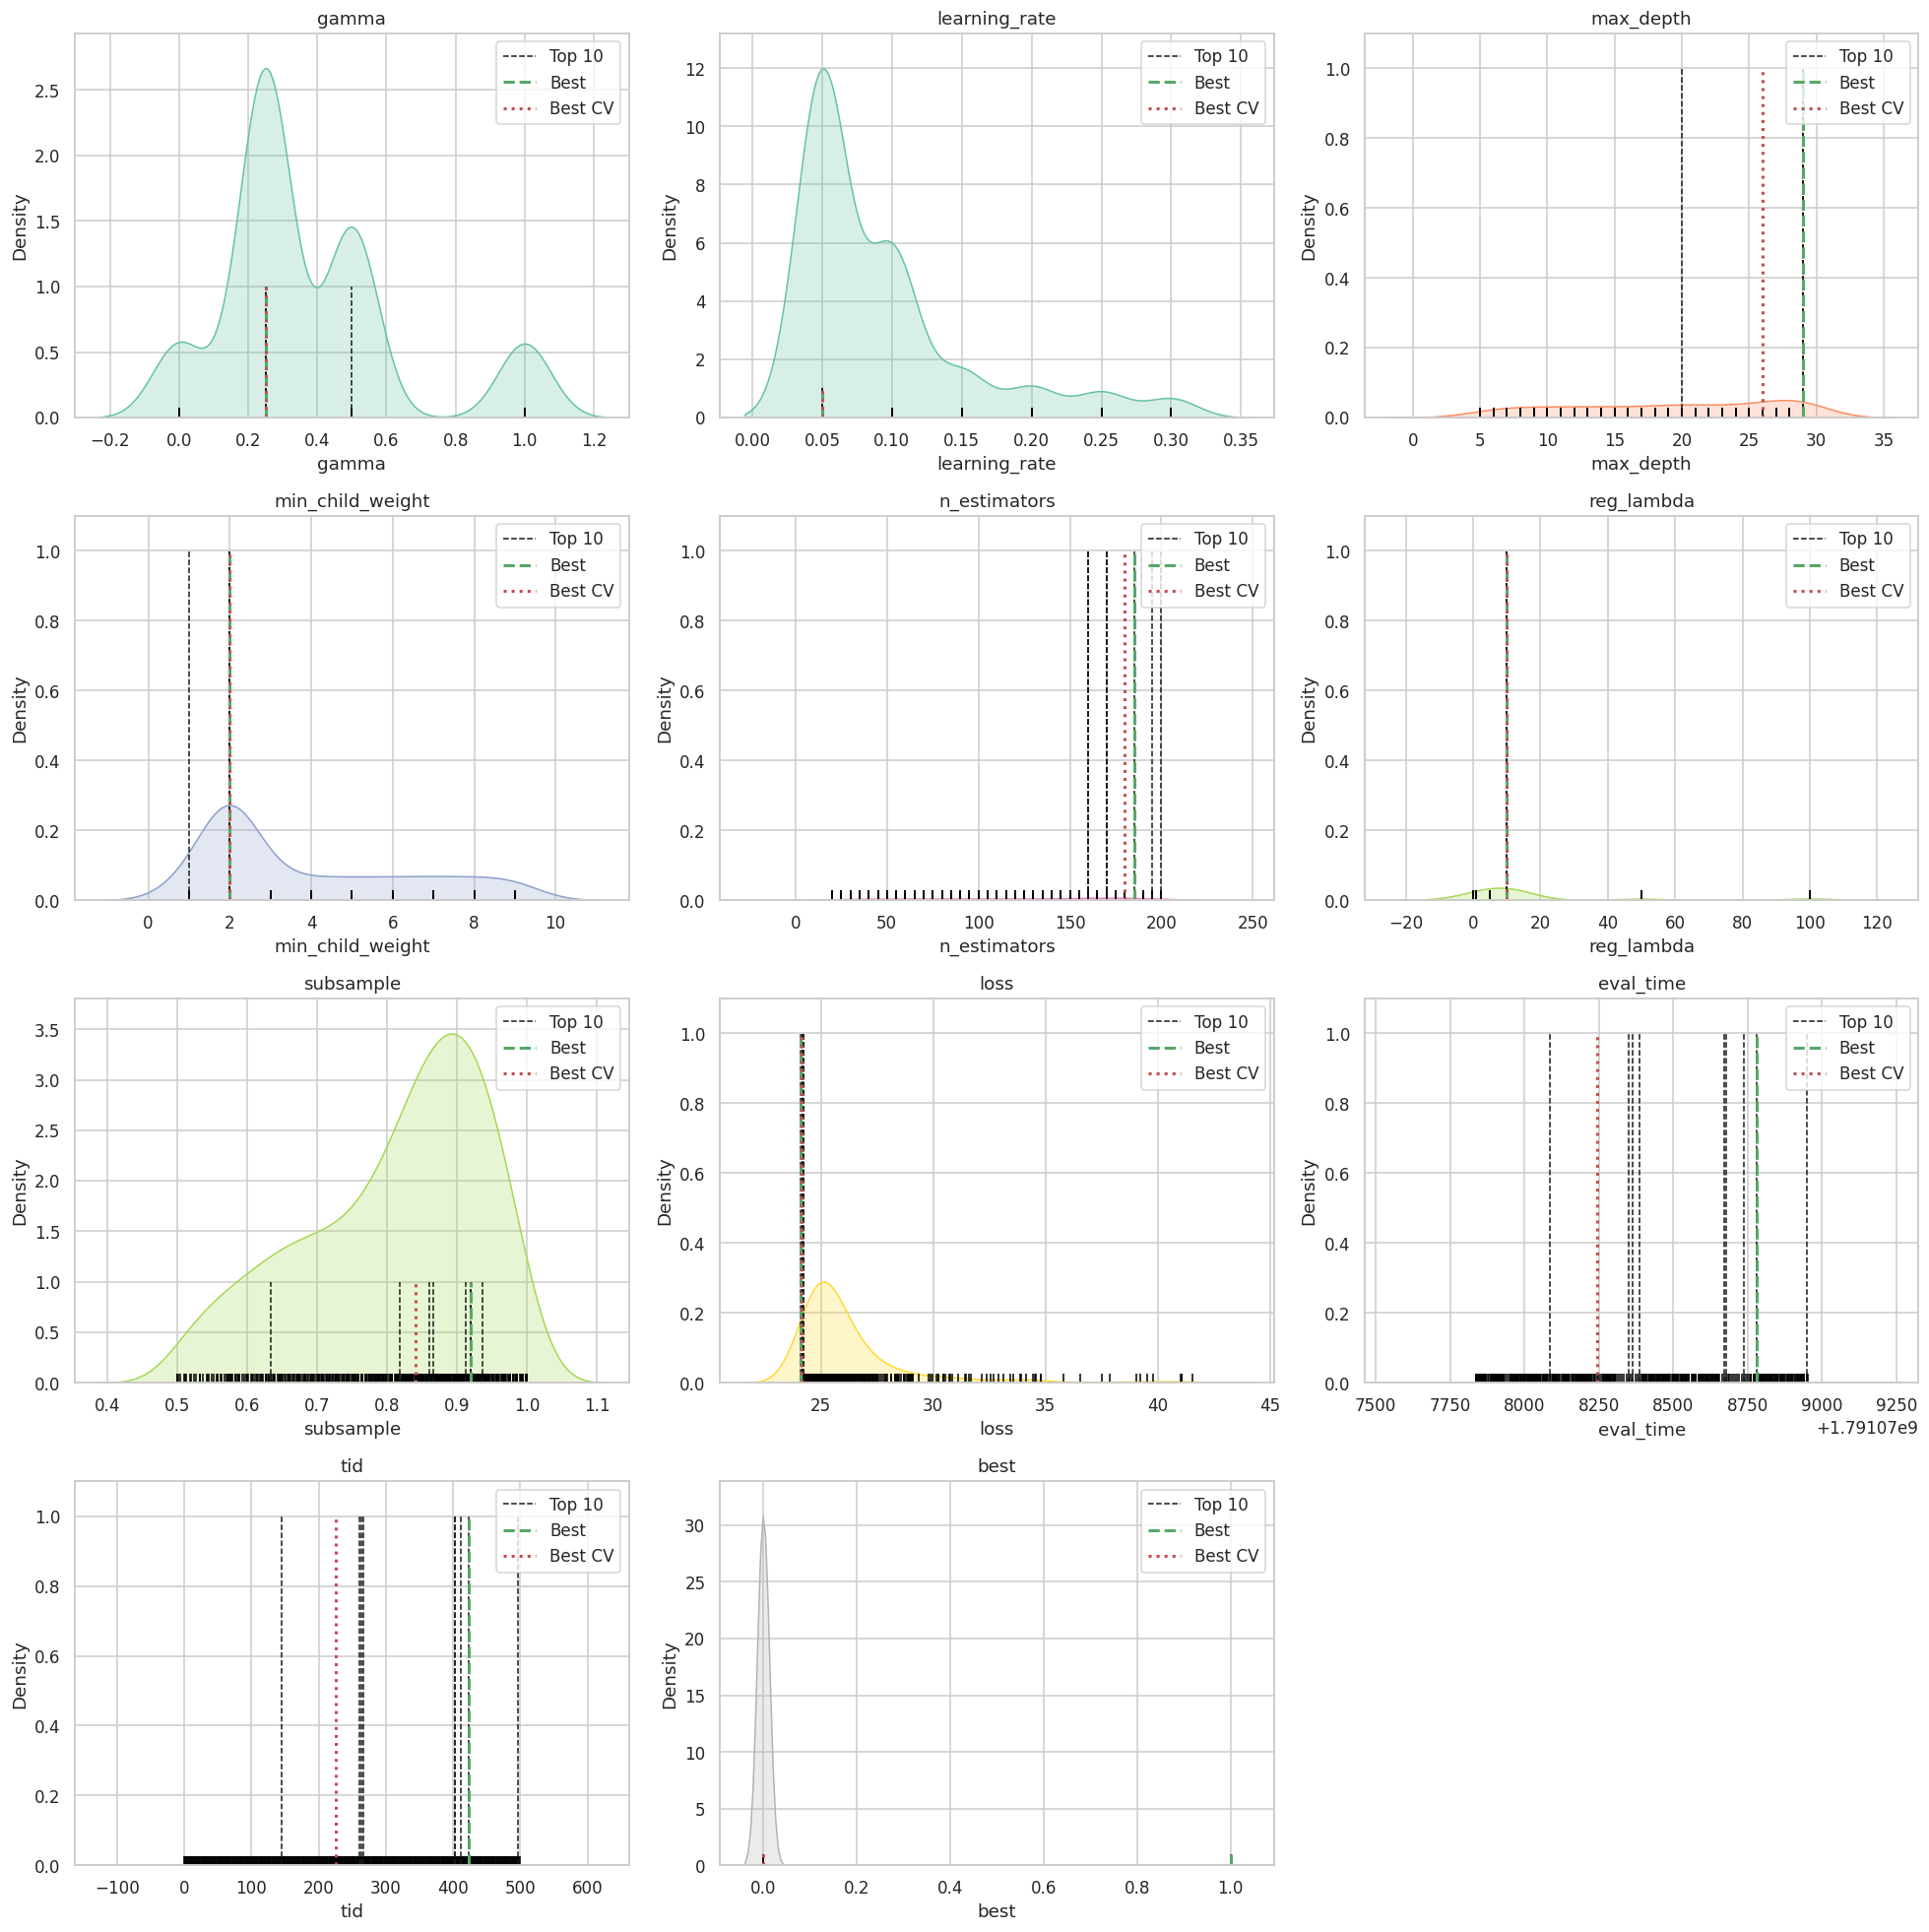

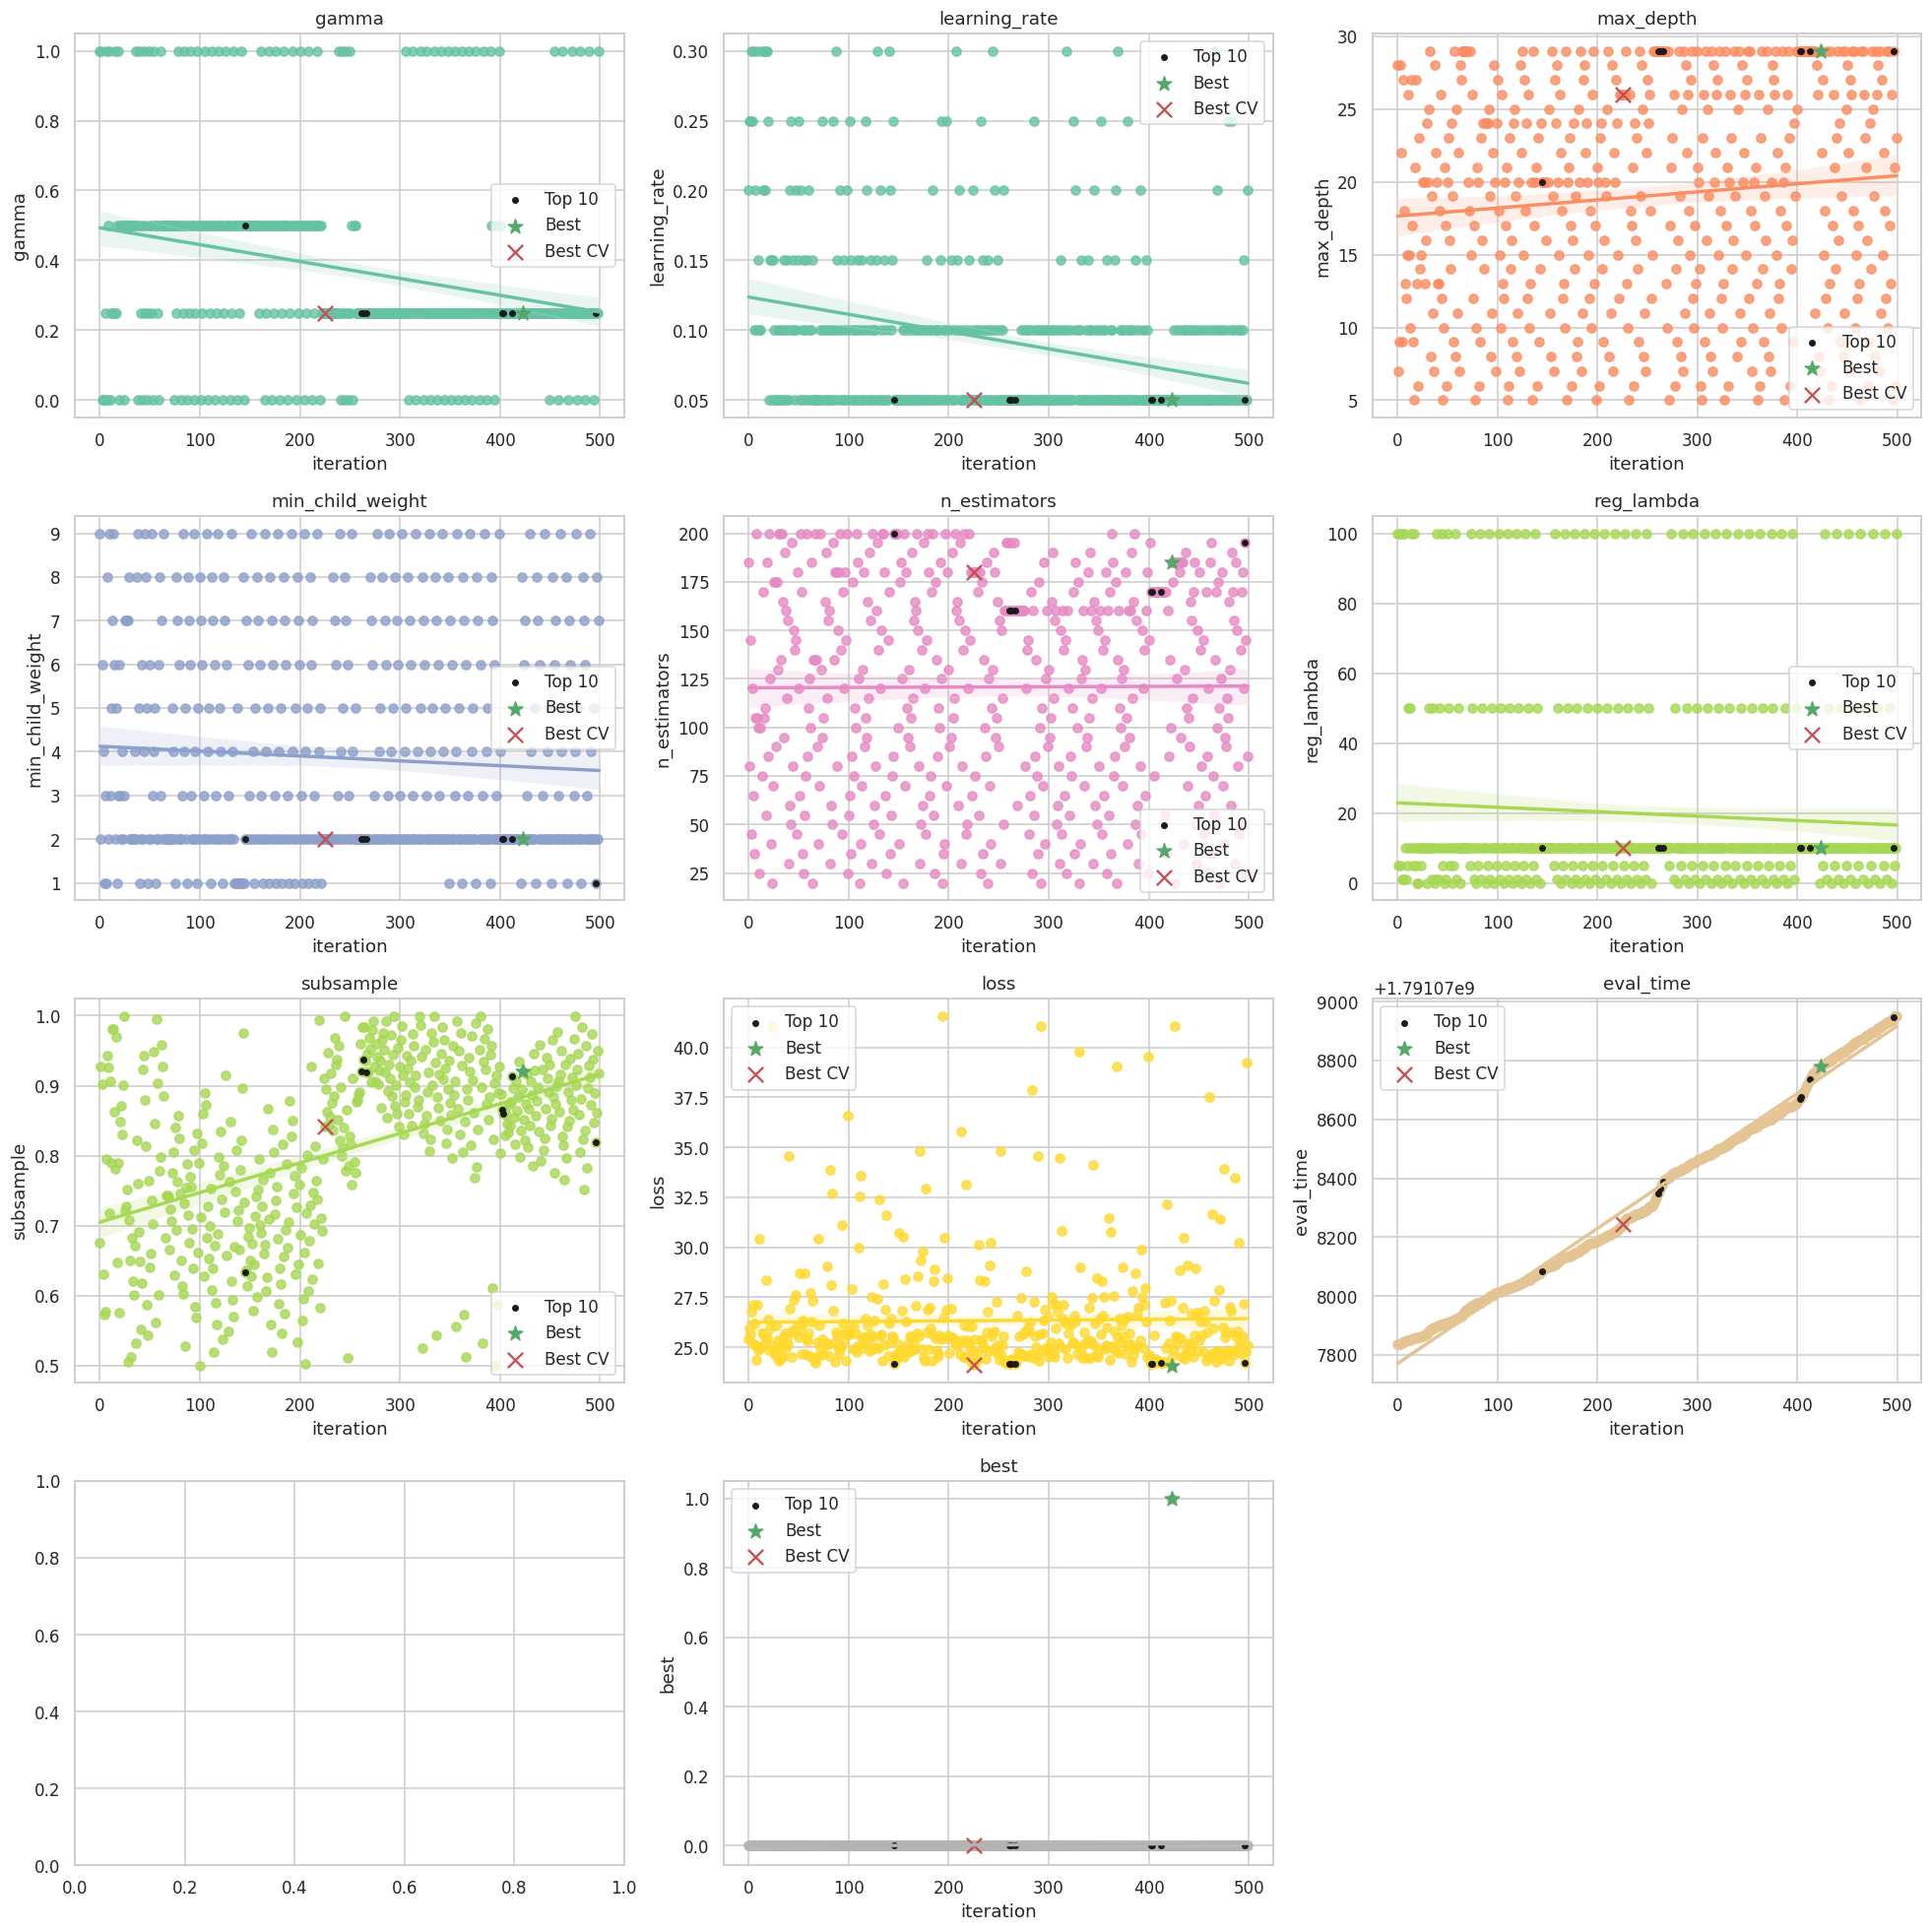

2026-10-04 02:31:44,100 5-fold crossvalidation is performed with [xgb_reg]
2026-10-04 02:31:44,121 No y_proba for xgb_reg
2026-10-04 02:31:44,139 No y_proba for xgb_reg
2026-10-04 02:31:44,157 No y_proba for xgb_reg
2026-10-04 02:31:44,174 No y_proba for xgb_reg
2026-10-04 02:31:44,192 No y_proba for xgb_reg


Saved /kaggle/working/output/figures/fig_08_figure.png


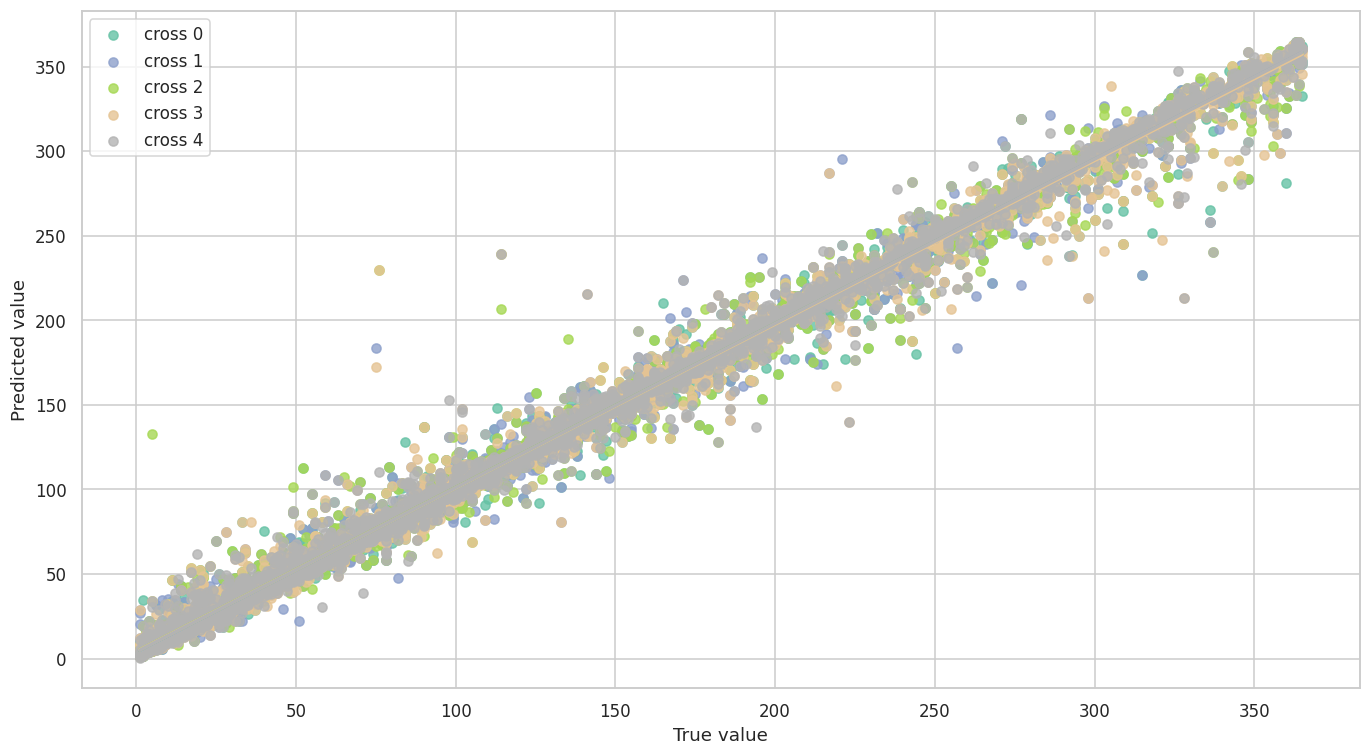

2026-10-04 02:31:46,383 No y_proba for xgb_reg


Saved /kaggle/working/output/figures/fig_09_results_on_independent_validation_set.png


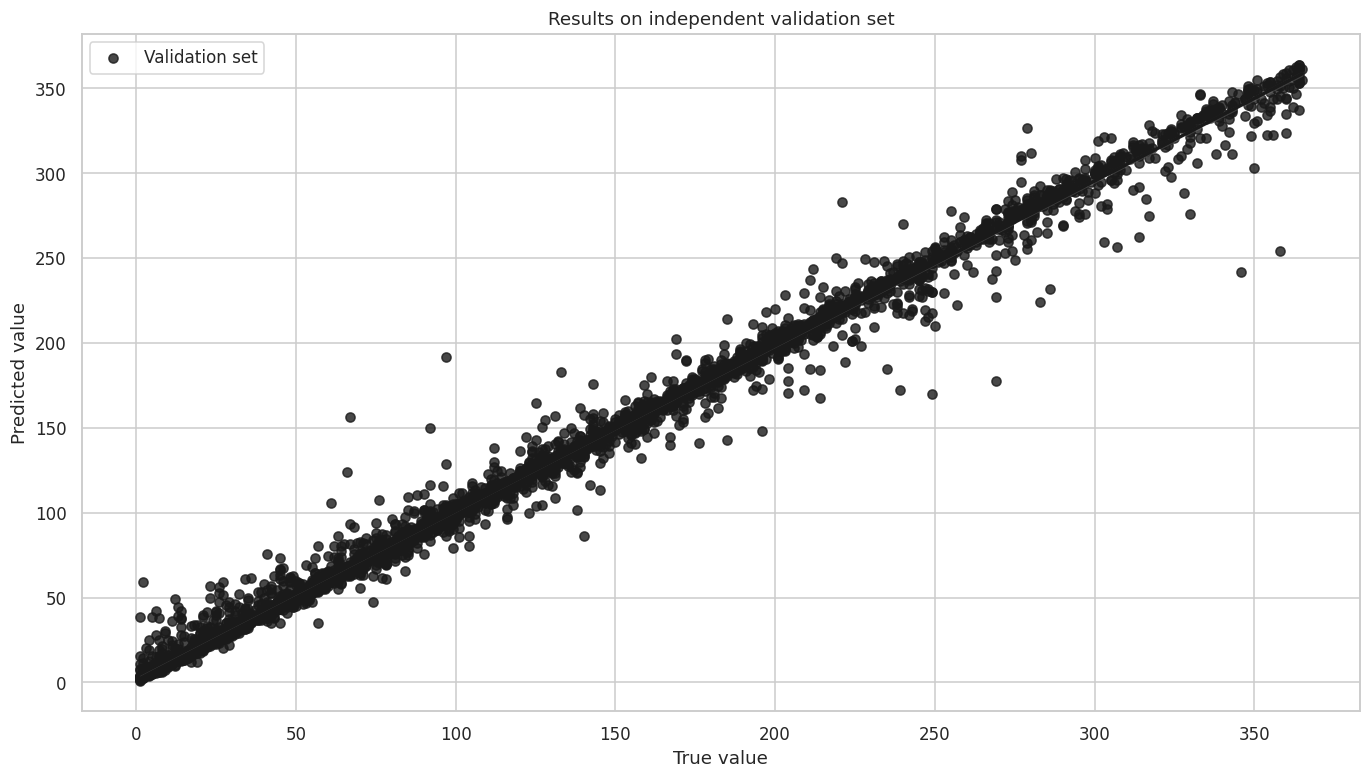

Saved /kaggle/working/output/figures/fig_10_xgboost_hyperparameter_trials.png


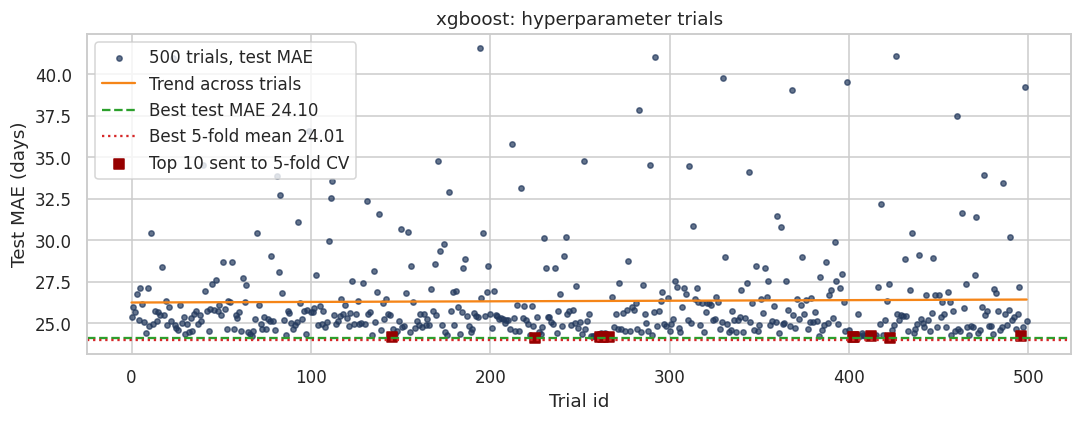

lightgbm
Saved /kaggle/working/output/figures/fig_11_lgb_reg_5_fold_cv_mean_mae_26_1.png


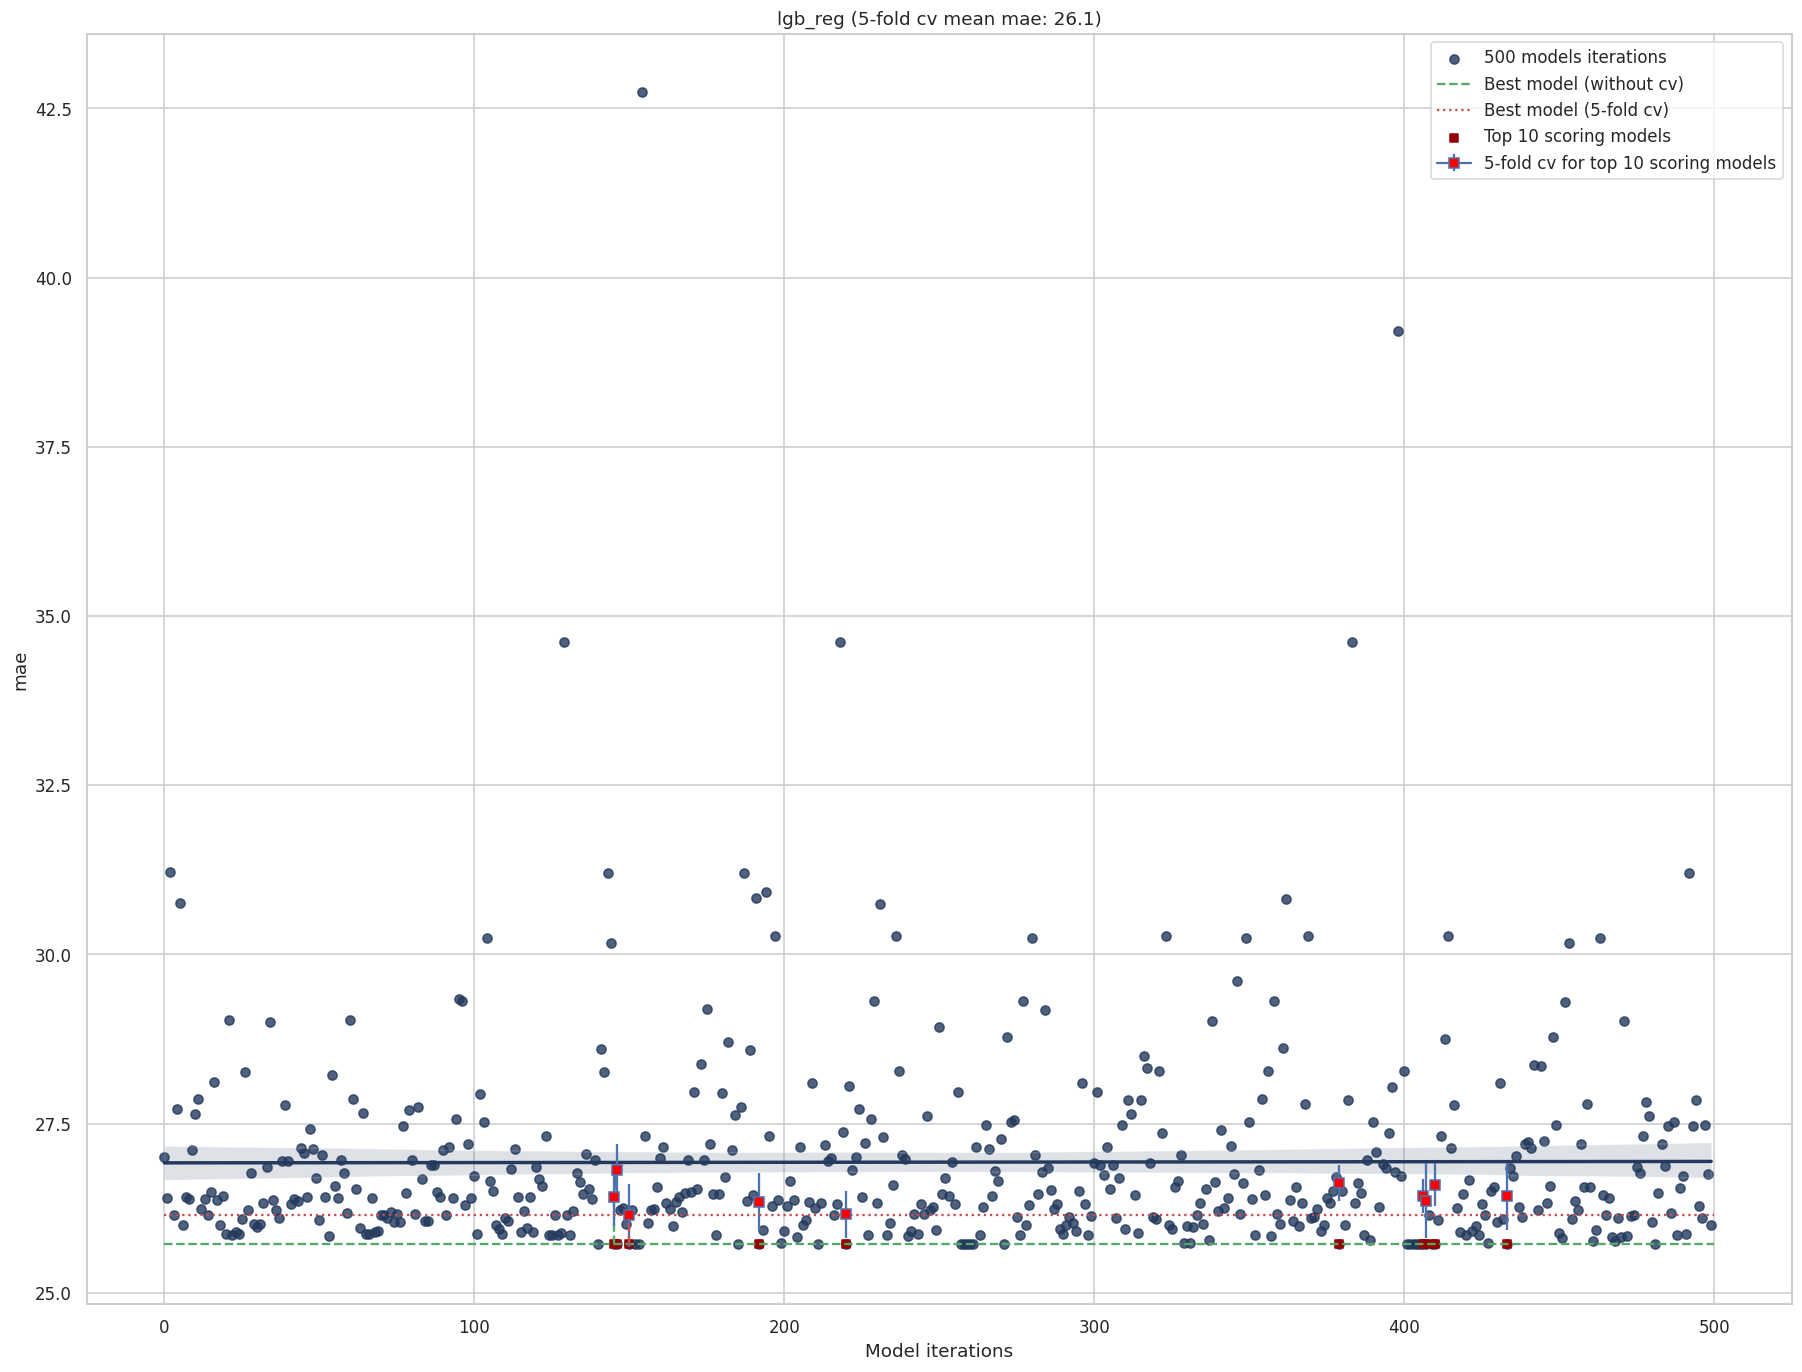

[04-10-2026 02:31:48] [colourmap.colourmap] [WARNING] Colormap [Set2] can not create [9] unique colors! Available unique colors: [8].
2026-10-04 02:31:49,959 Scatter plot failed [tid]: arg must be a list, tuple, 1-d array, or Series


Saved /kaggle/working/output/figures/fig_12_learning_rate.png


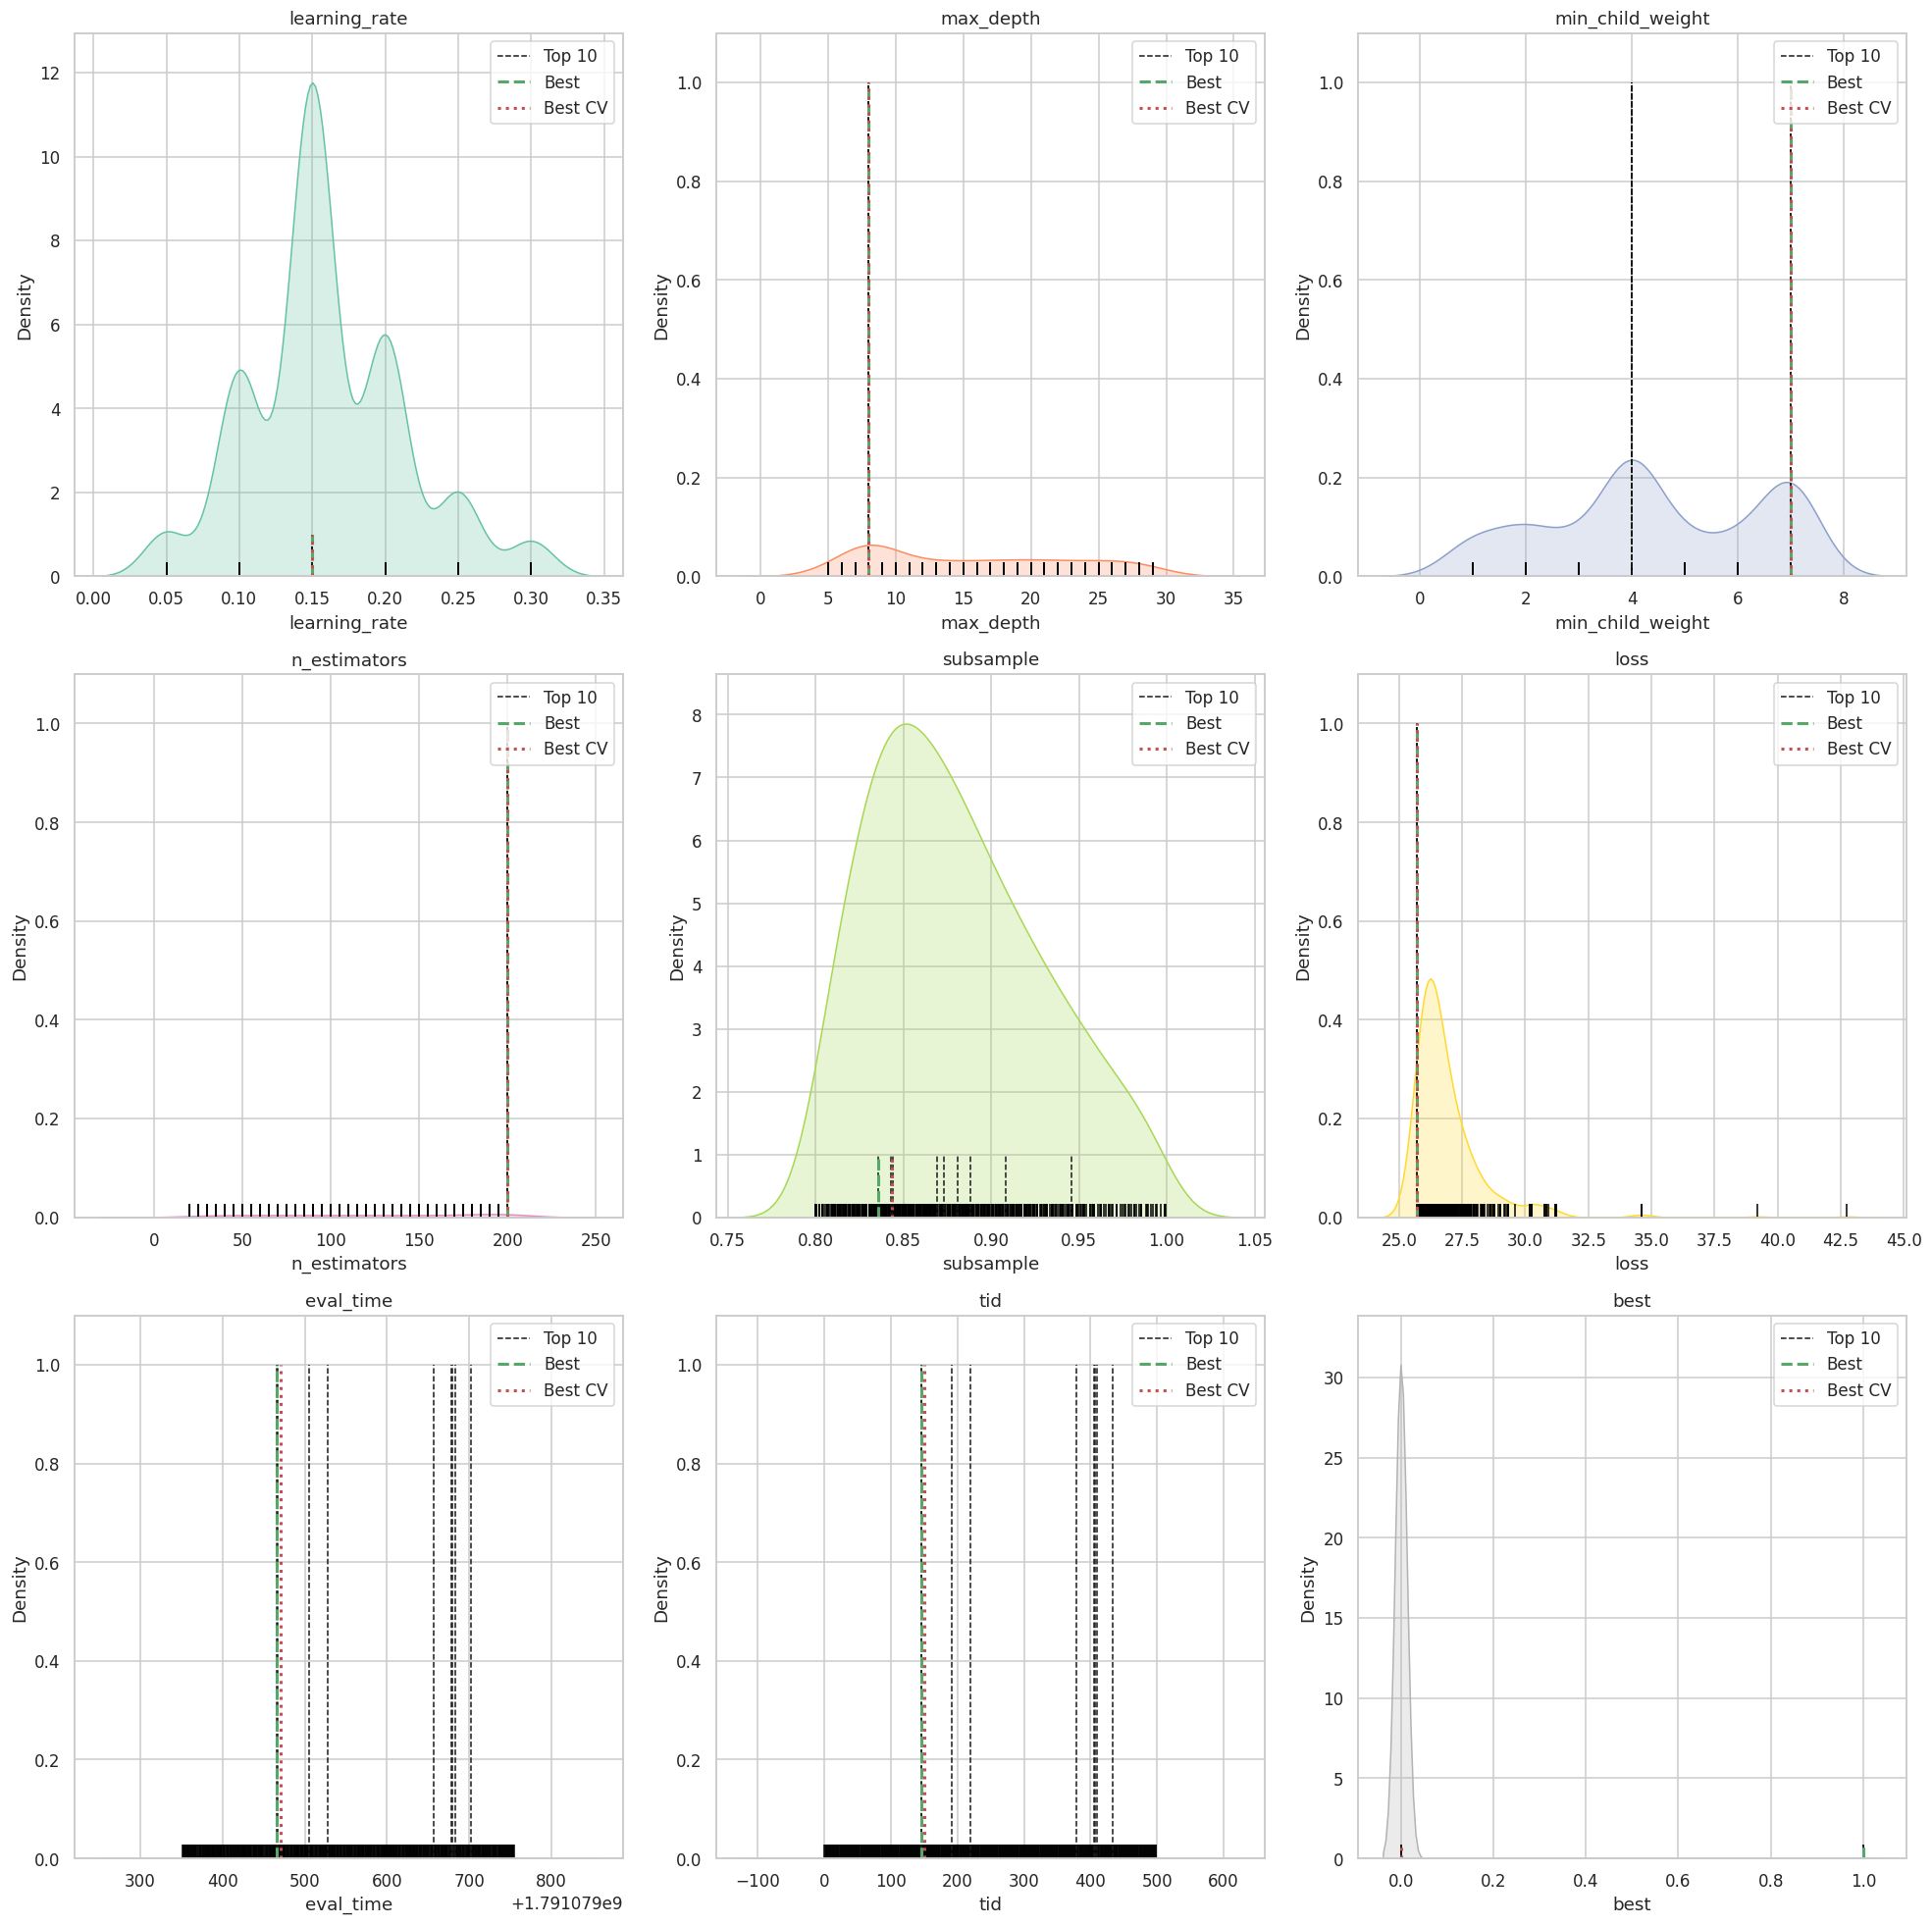

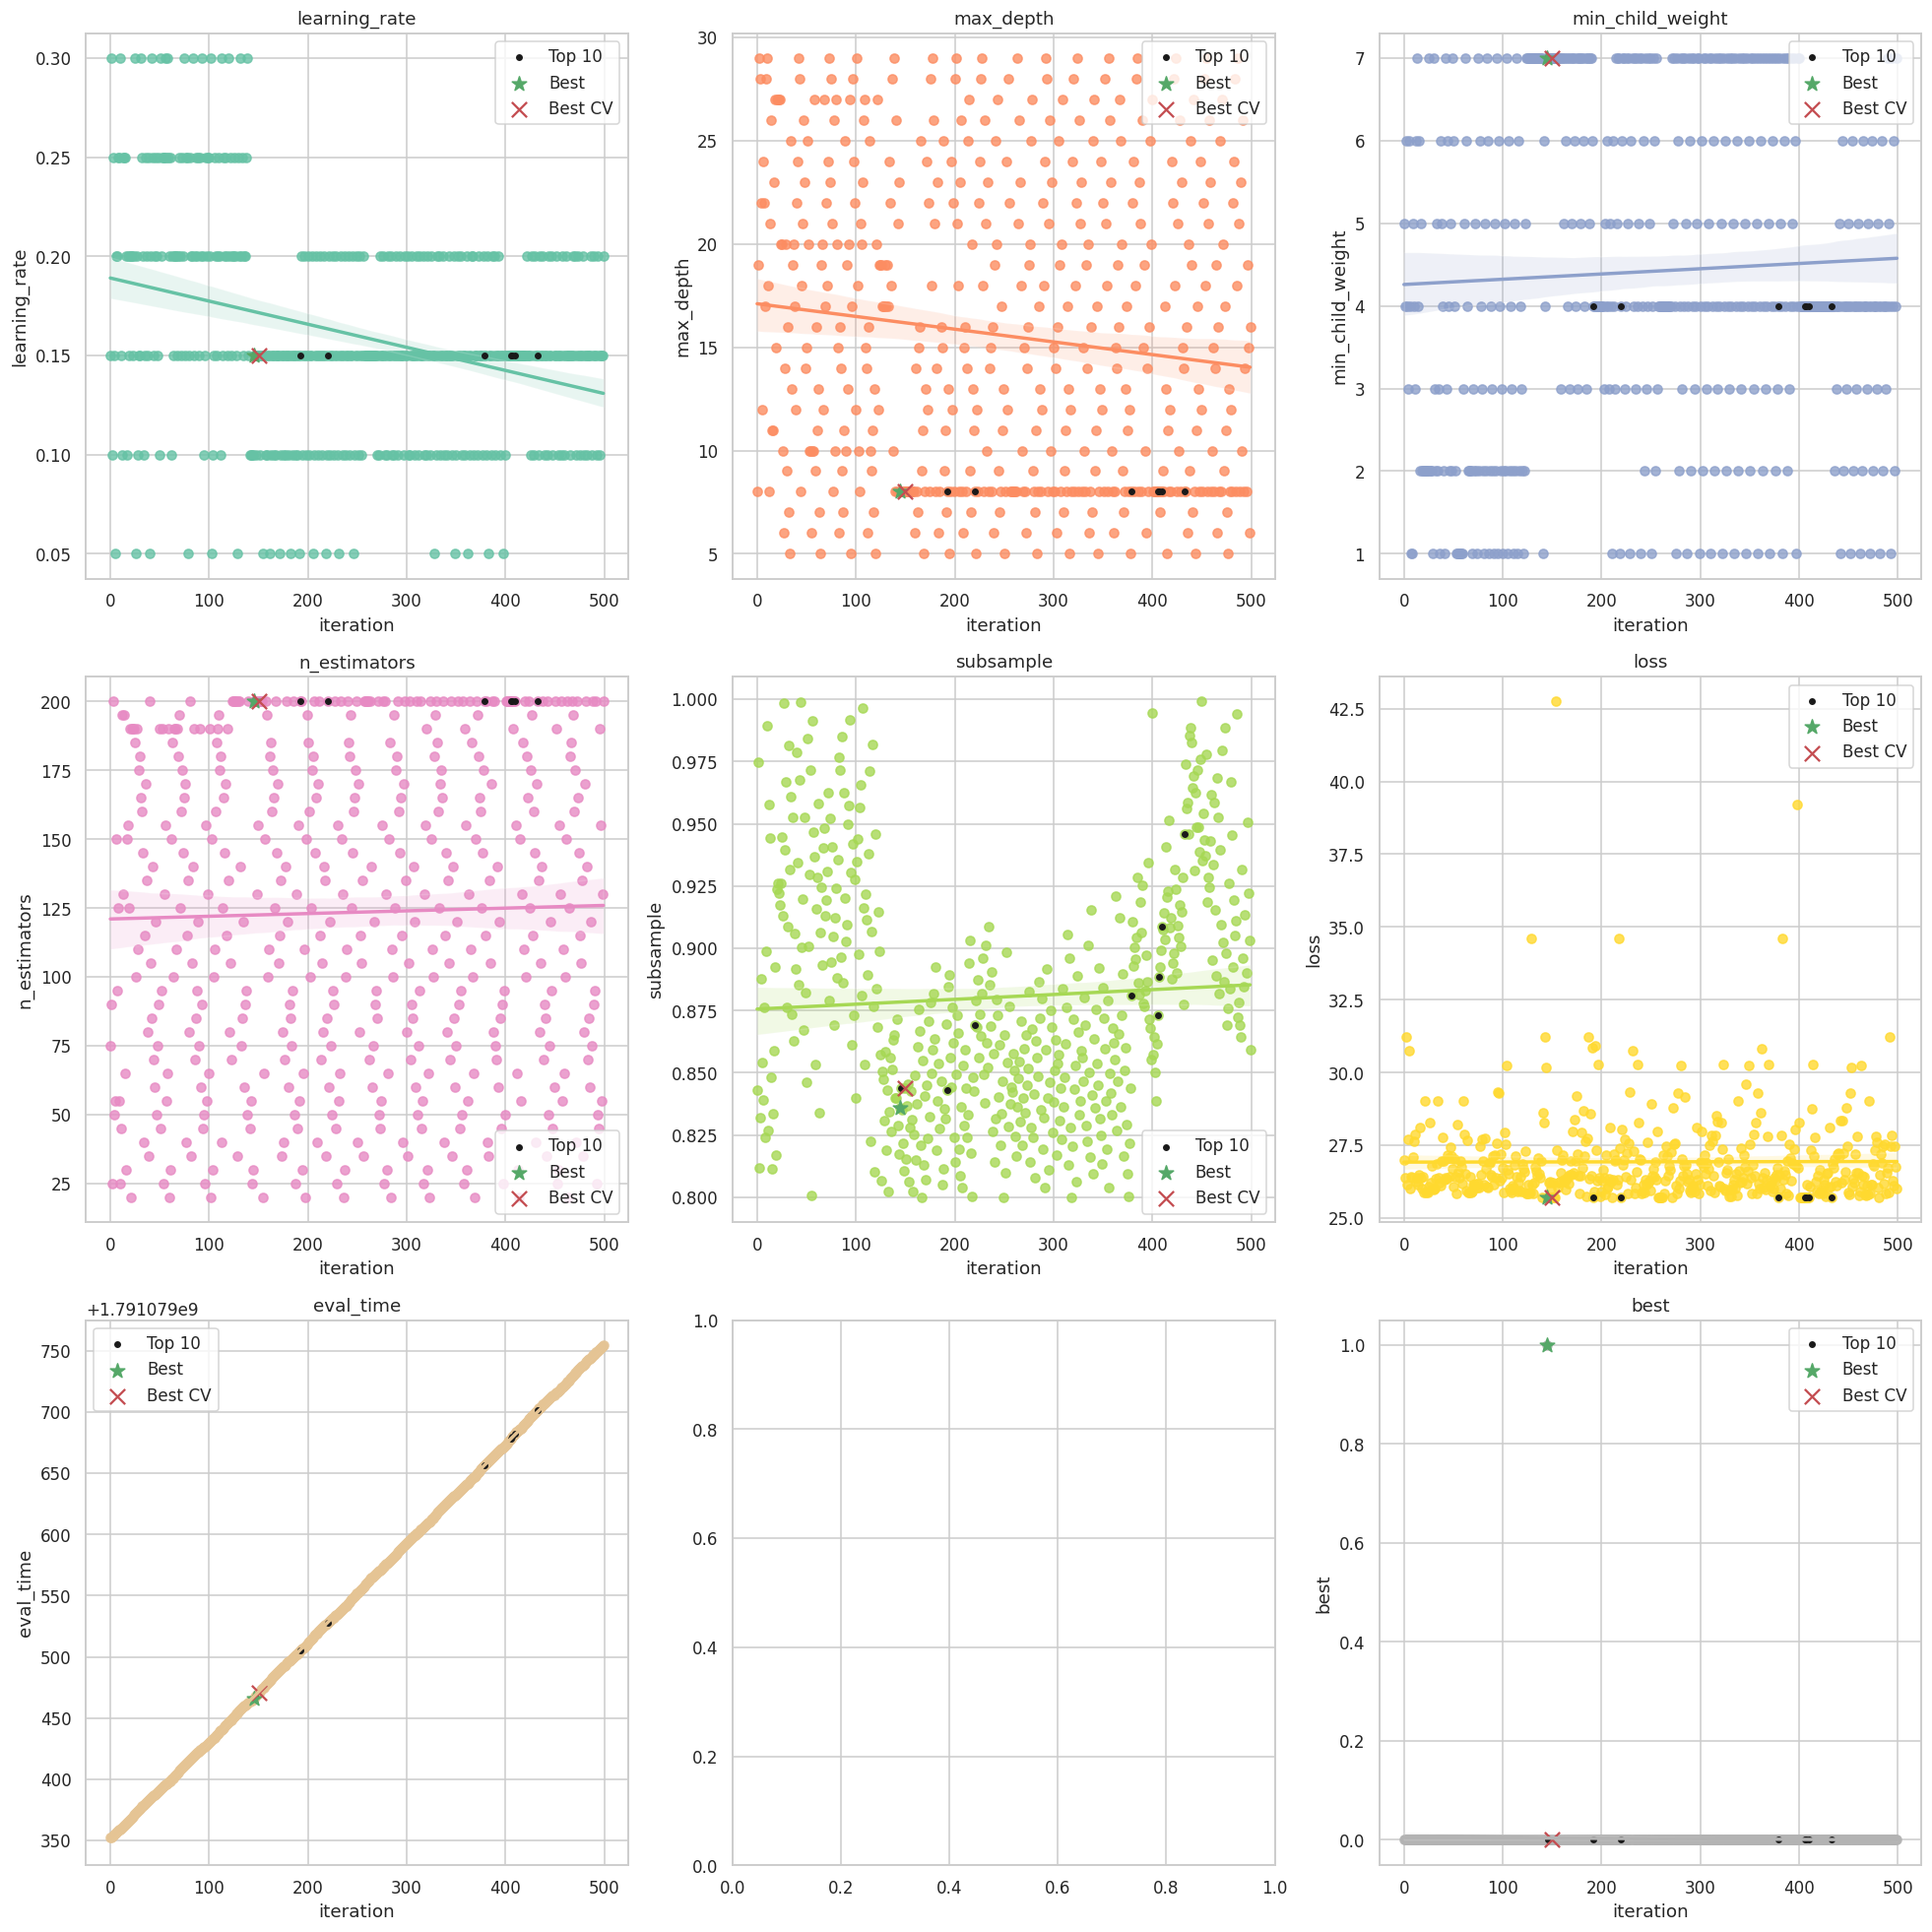

2026-10-04 02:31:53,926 5-fold crossvalidation is performed with [lgb_reg]
2026-10-04 02:31:53,984 No y_proba for lgb_reg
2026-10-04 02:31:54,043 No y_proba for lgb_reg
2026-10-04 02:31:54,102 No y_proba for lgb_reg
2026-10-04 02:31:54,160 No y_proba for lgb_reg
2026-10-04 02:31:54,218 No y_proba for lgb_reg


Saved /kaggle/working/output/figures/fig_13_figure.png


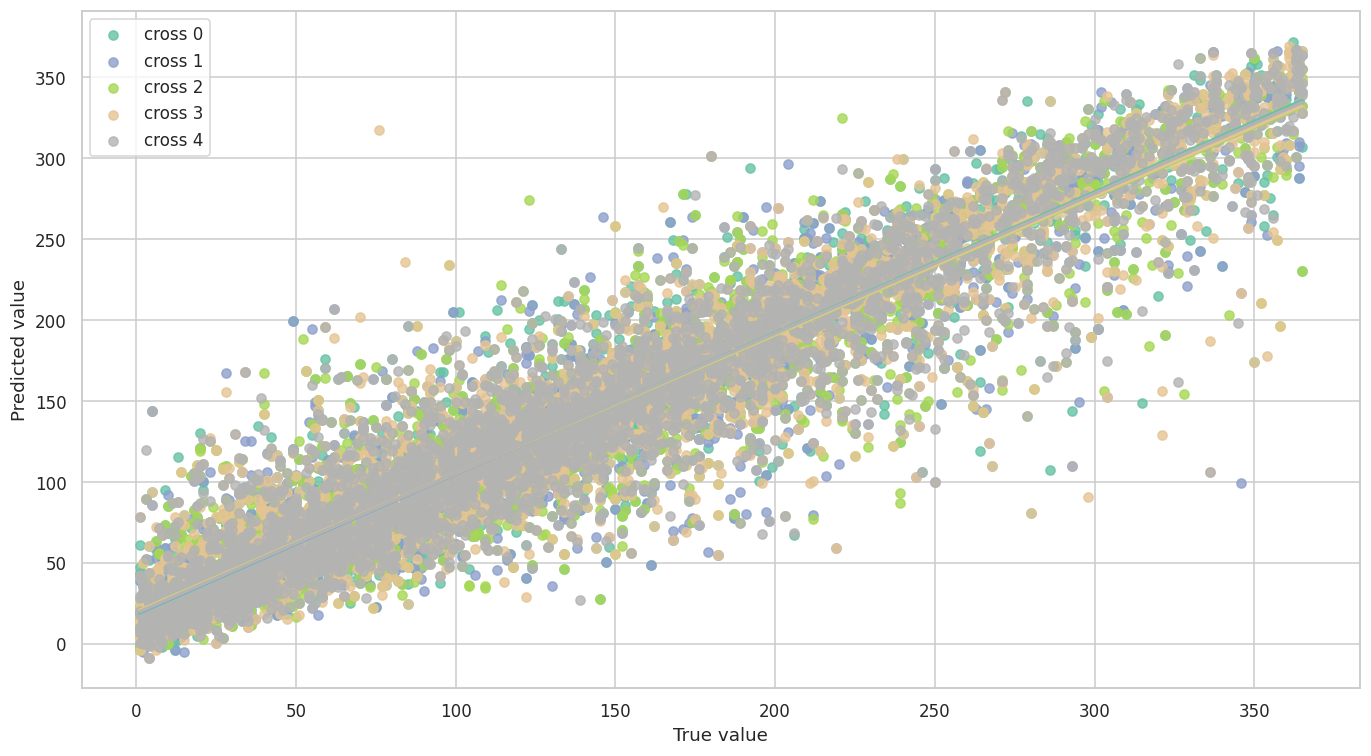

2026-10-04 02:31:56,556 No y_proba for lgb_reg


Saved /kaggle/working/output/figures/fig_14_results_on_independent_validation_set.png


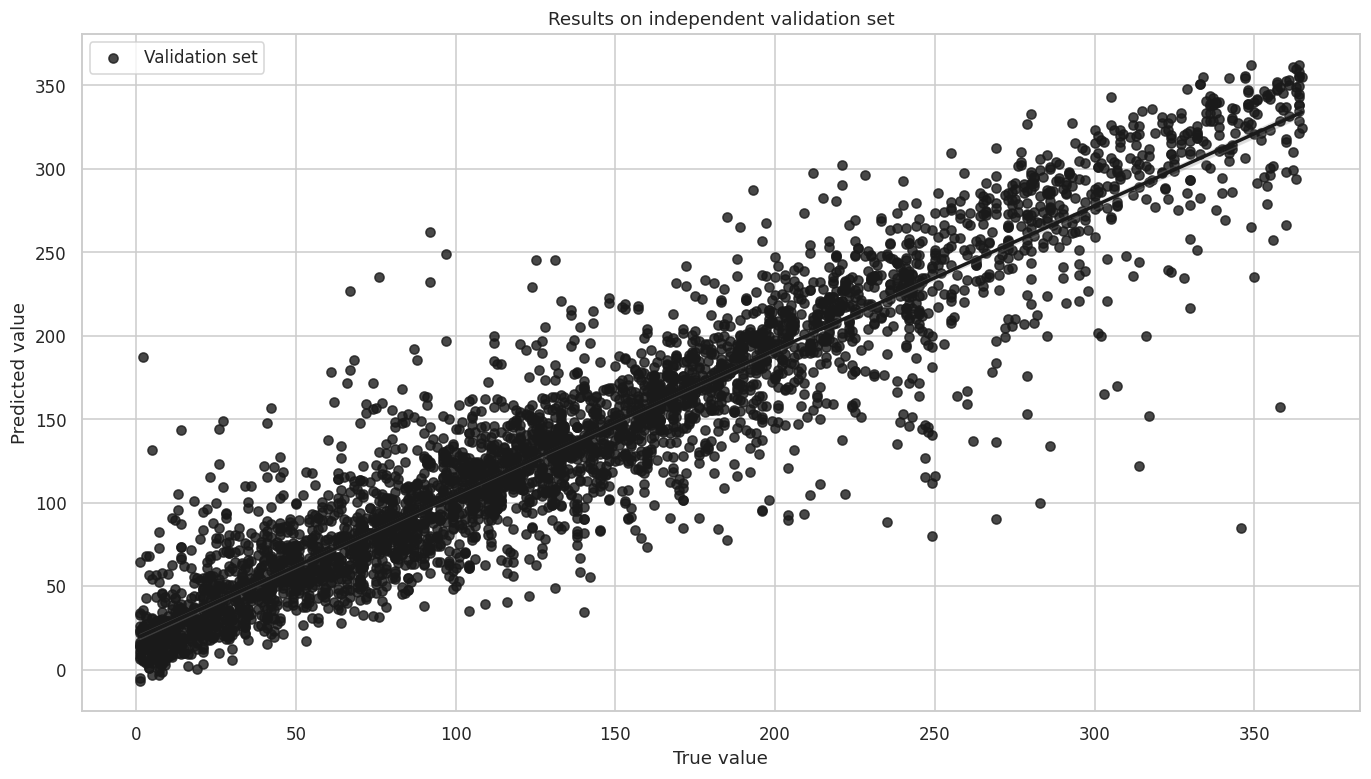

Saved /kaggle/working/output/figures/fig_15_lightgbm_hyperparameter_trials.png


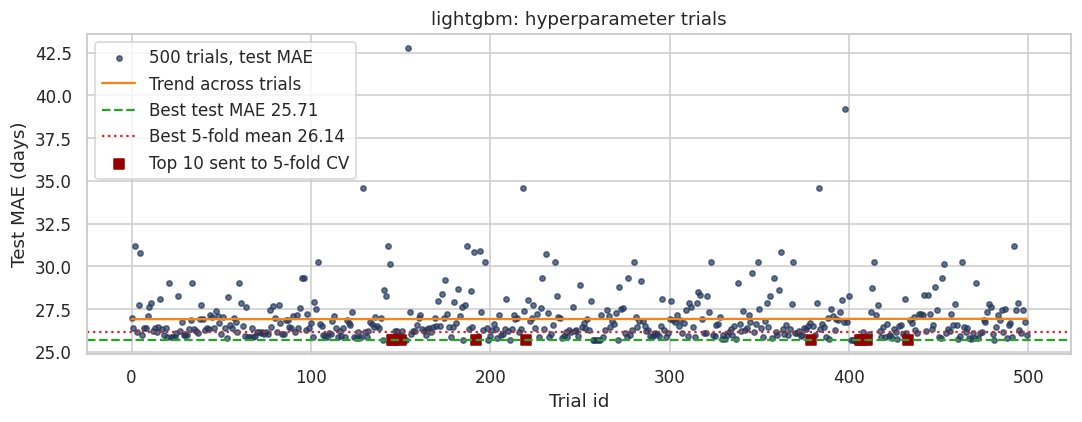

catboost
Saved /kaggle/working/output/figures/fig_16_ctb_reg_5_fold_cv_mean_mae_25_3.png


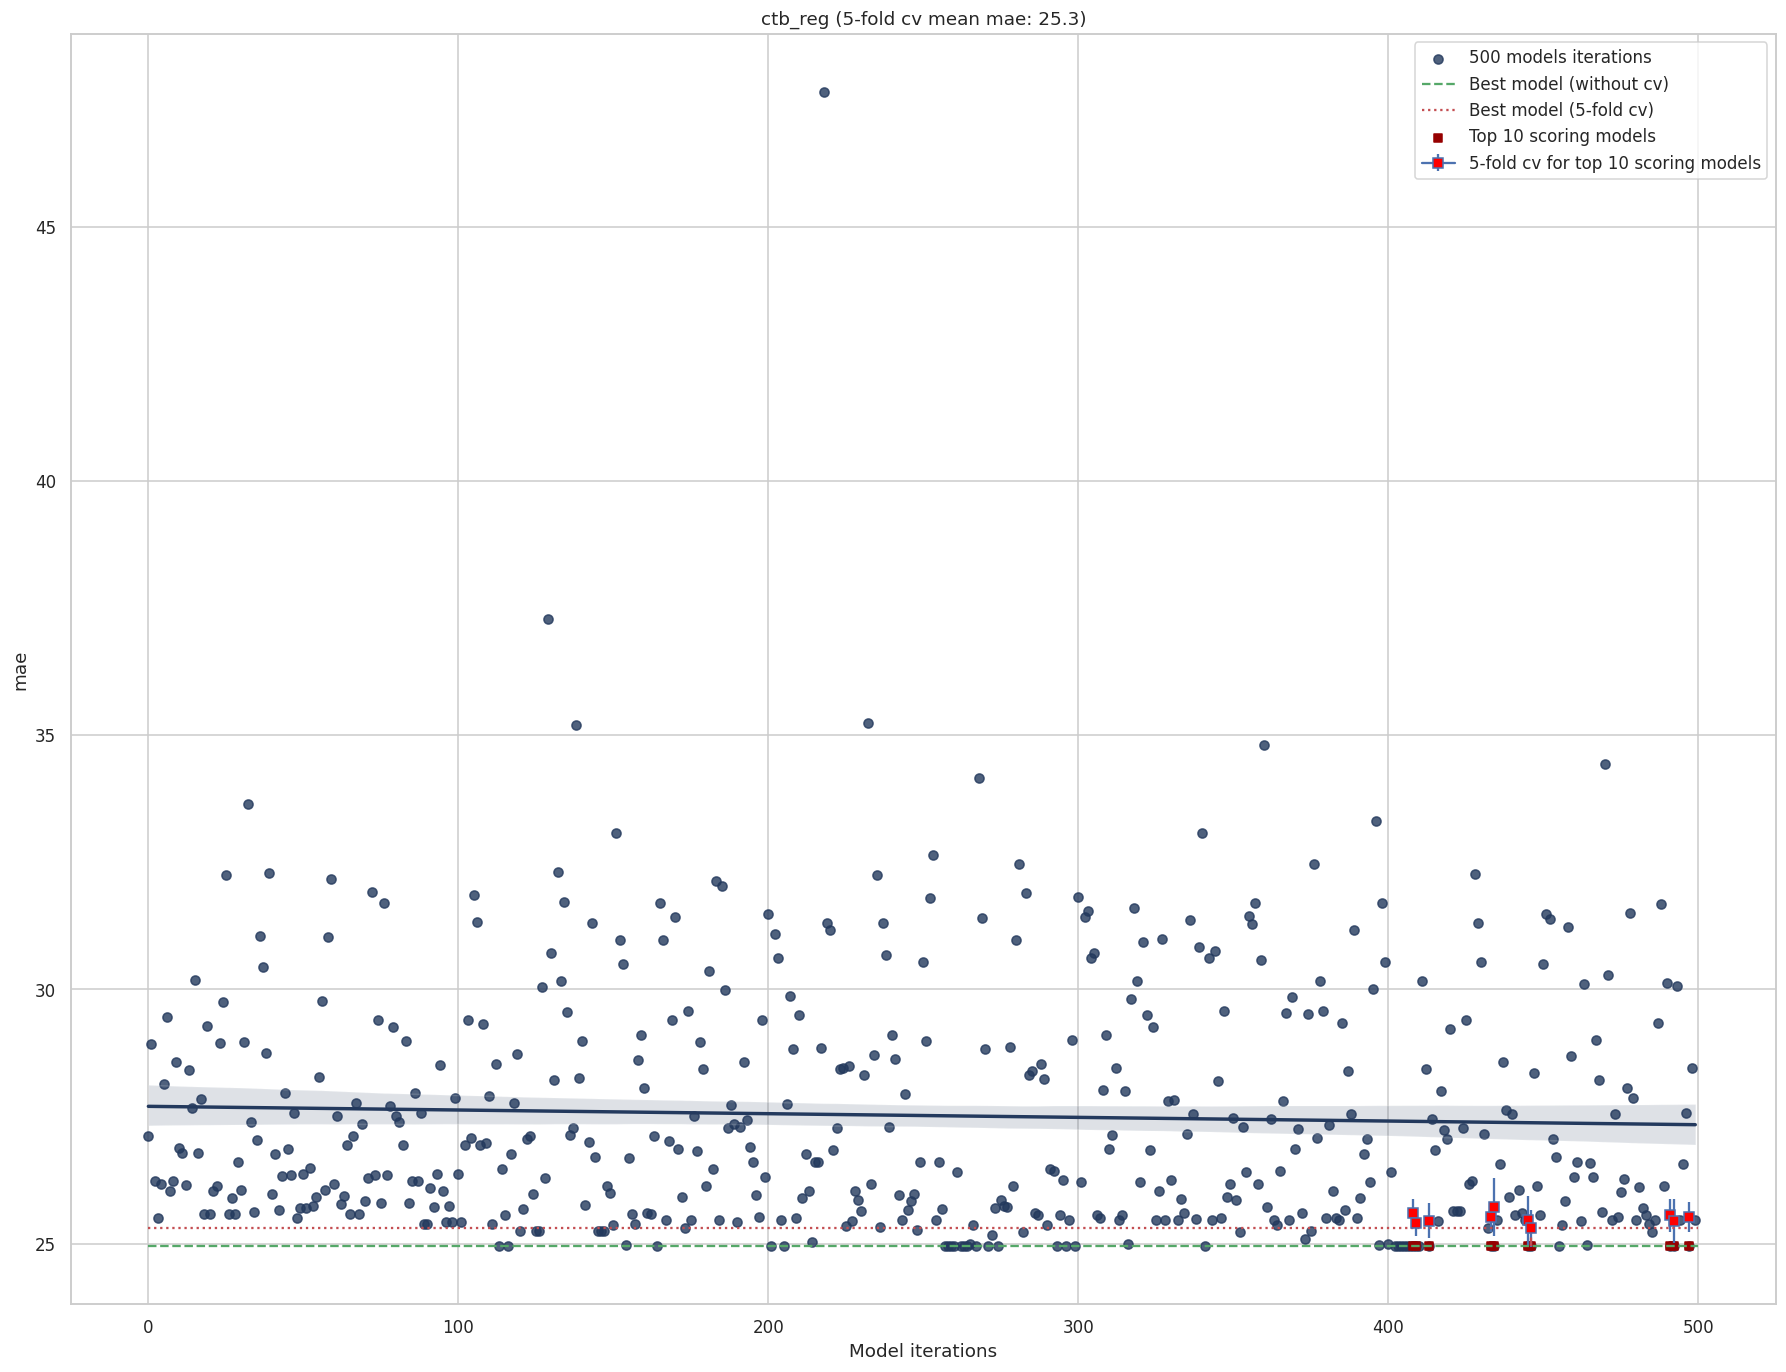

2026-10-04 02:31:59,504 Scatter plot failed [tid]: arg must be a list, tuple, 1-d array, or Series


Saved /kaggle/working/output/figures/fig_17_learning_rate.png


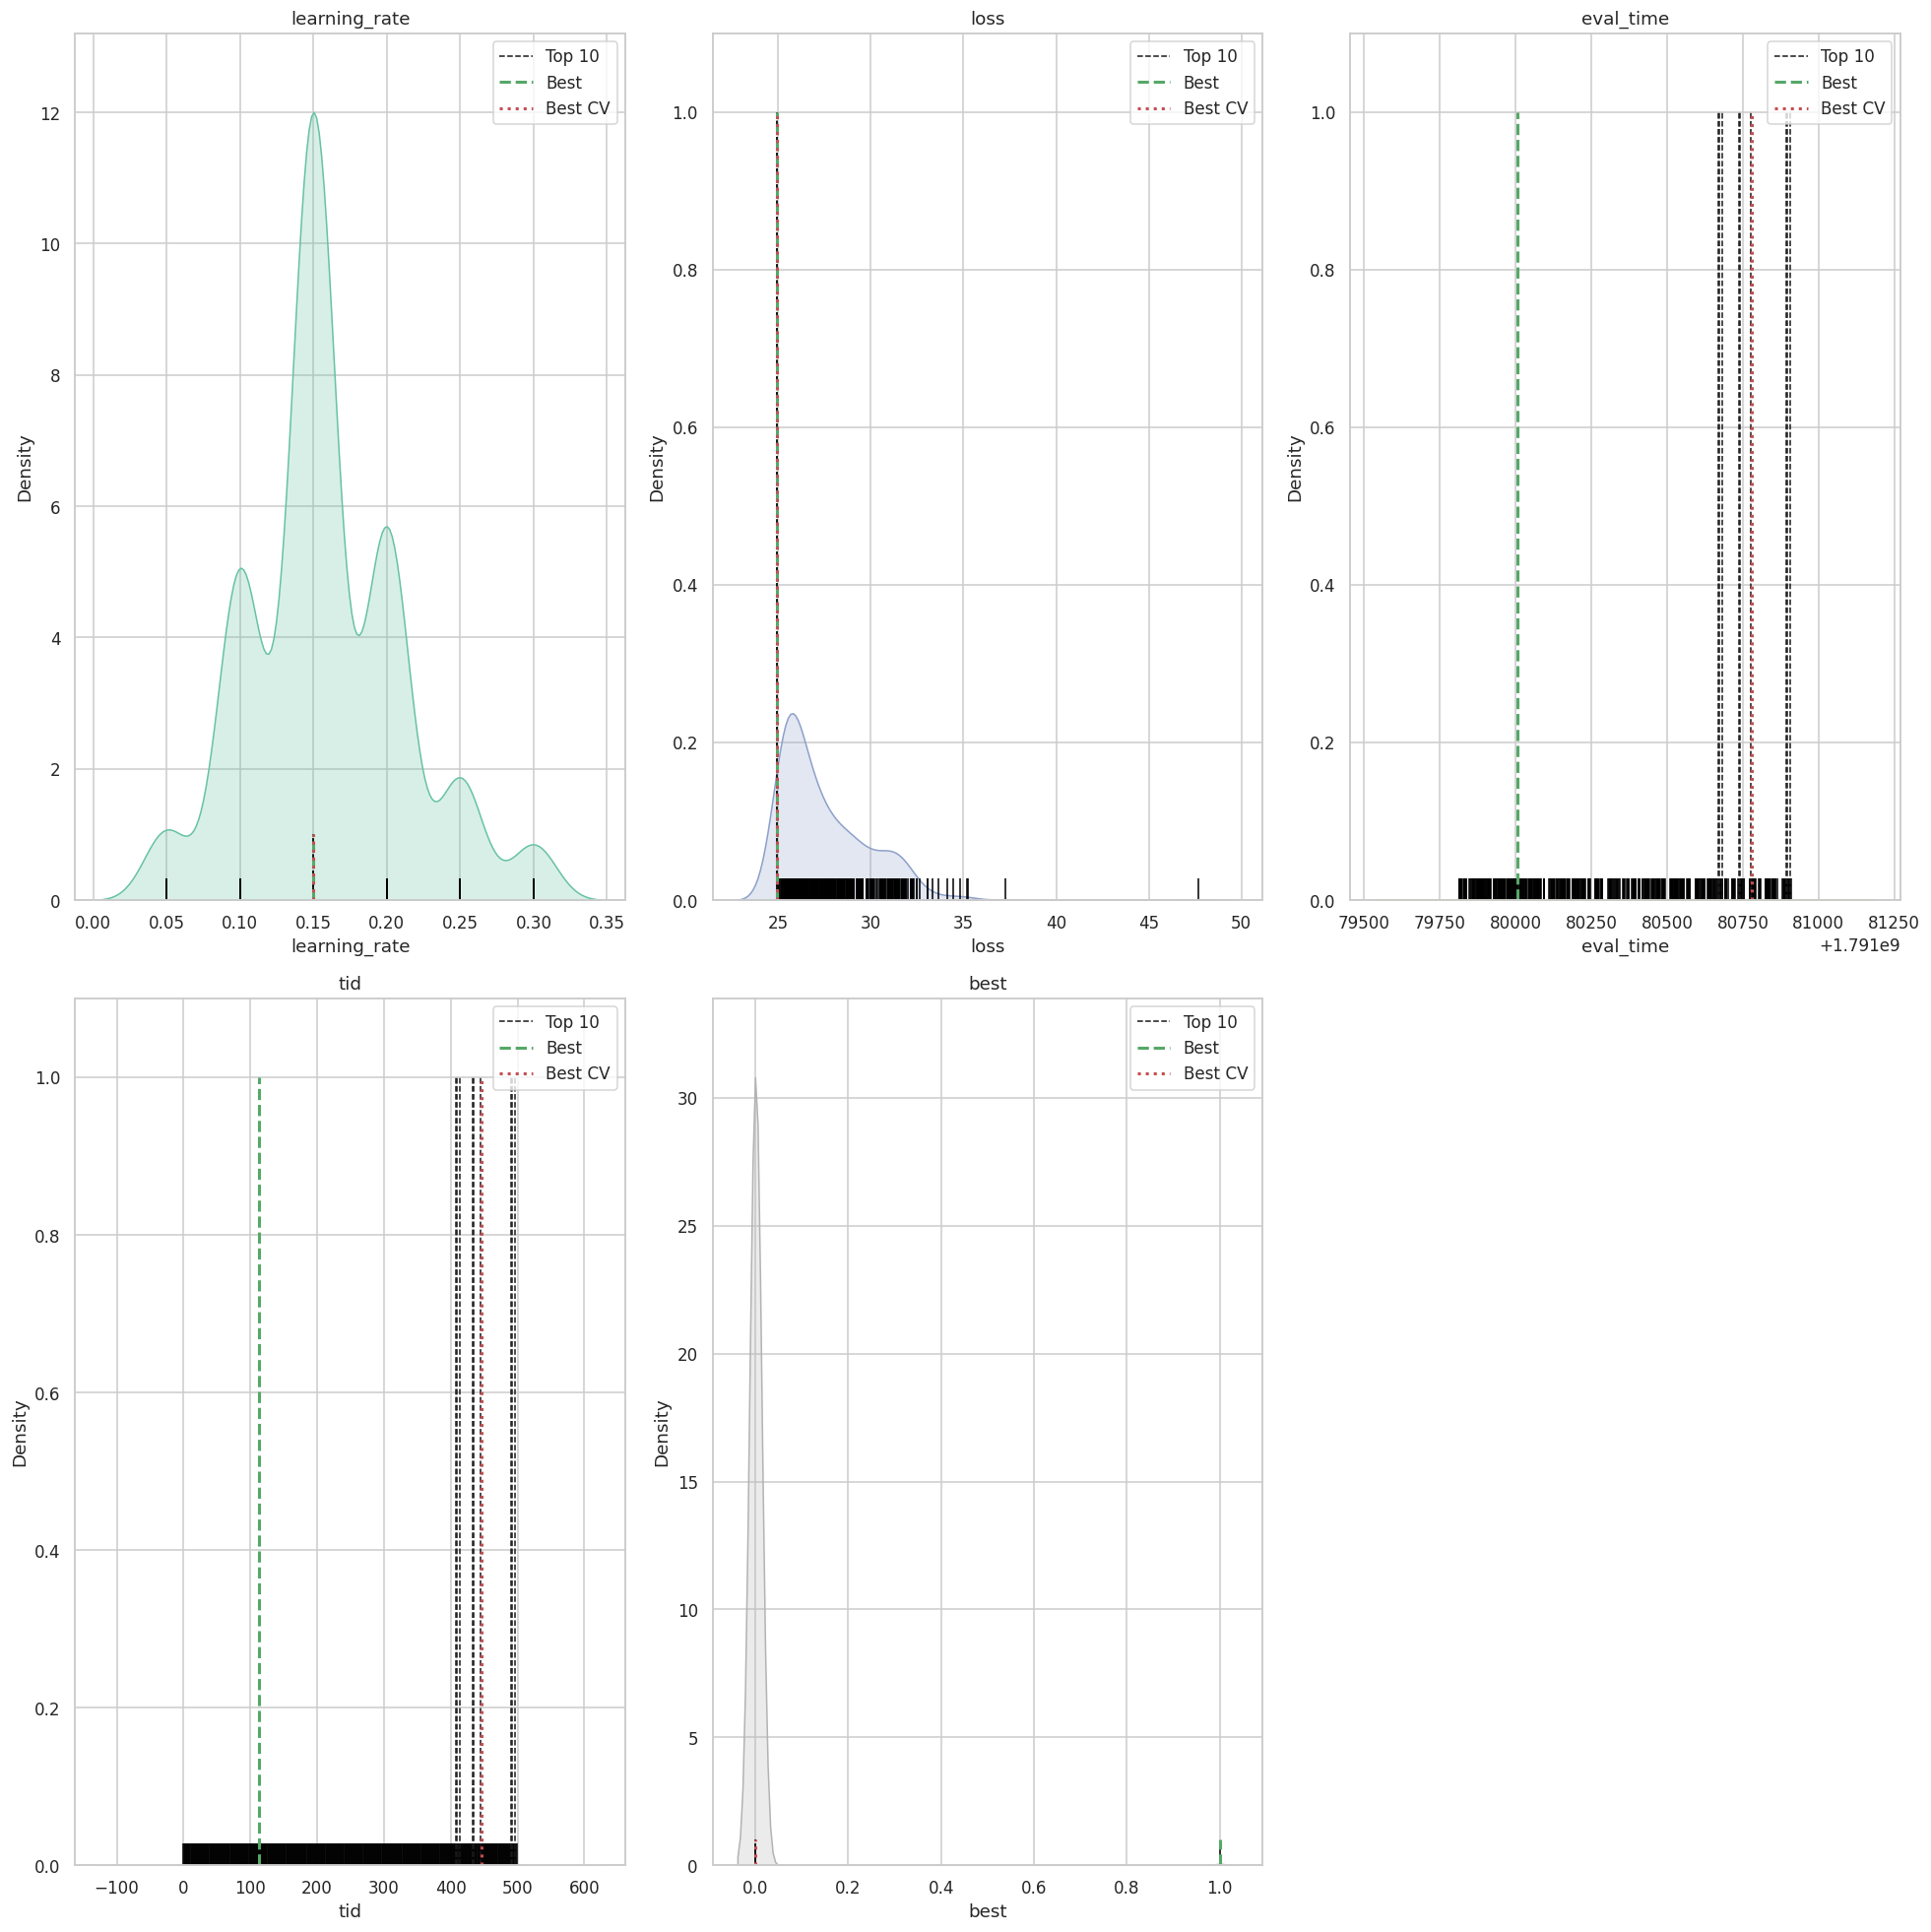

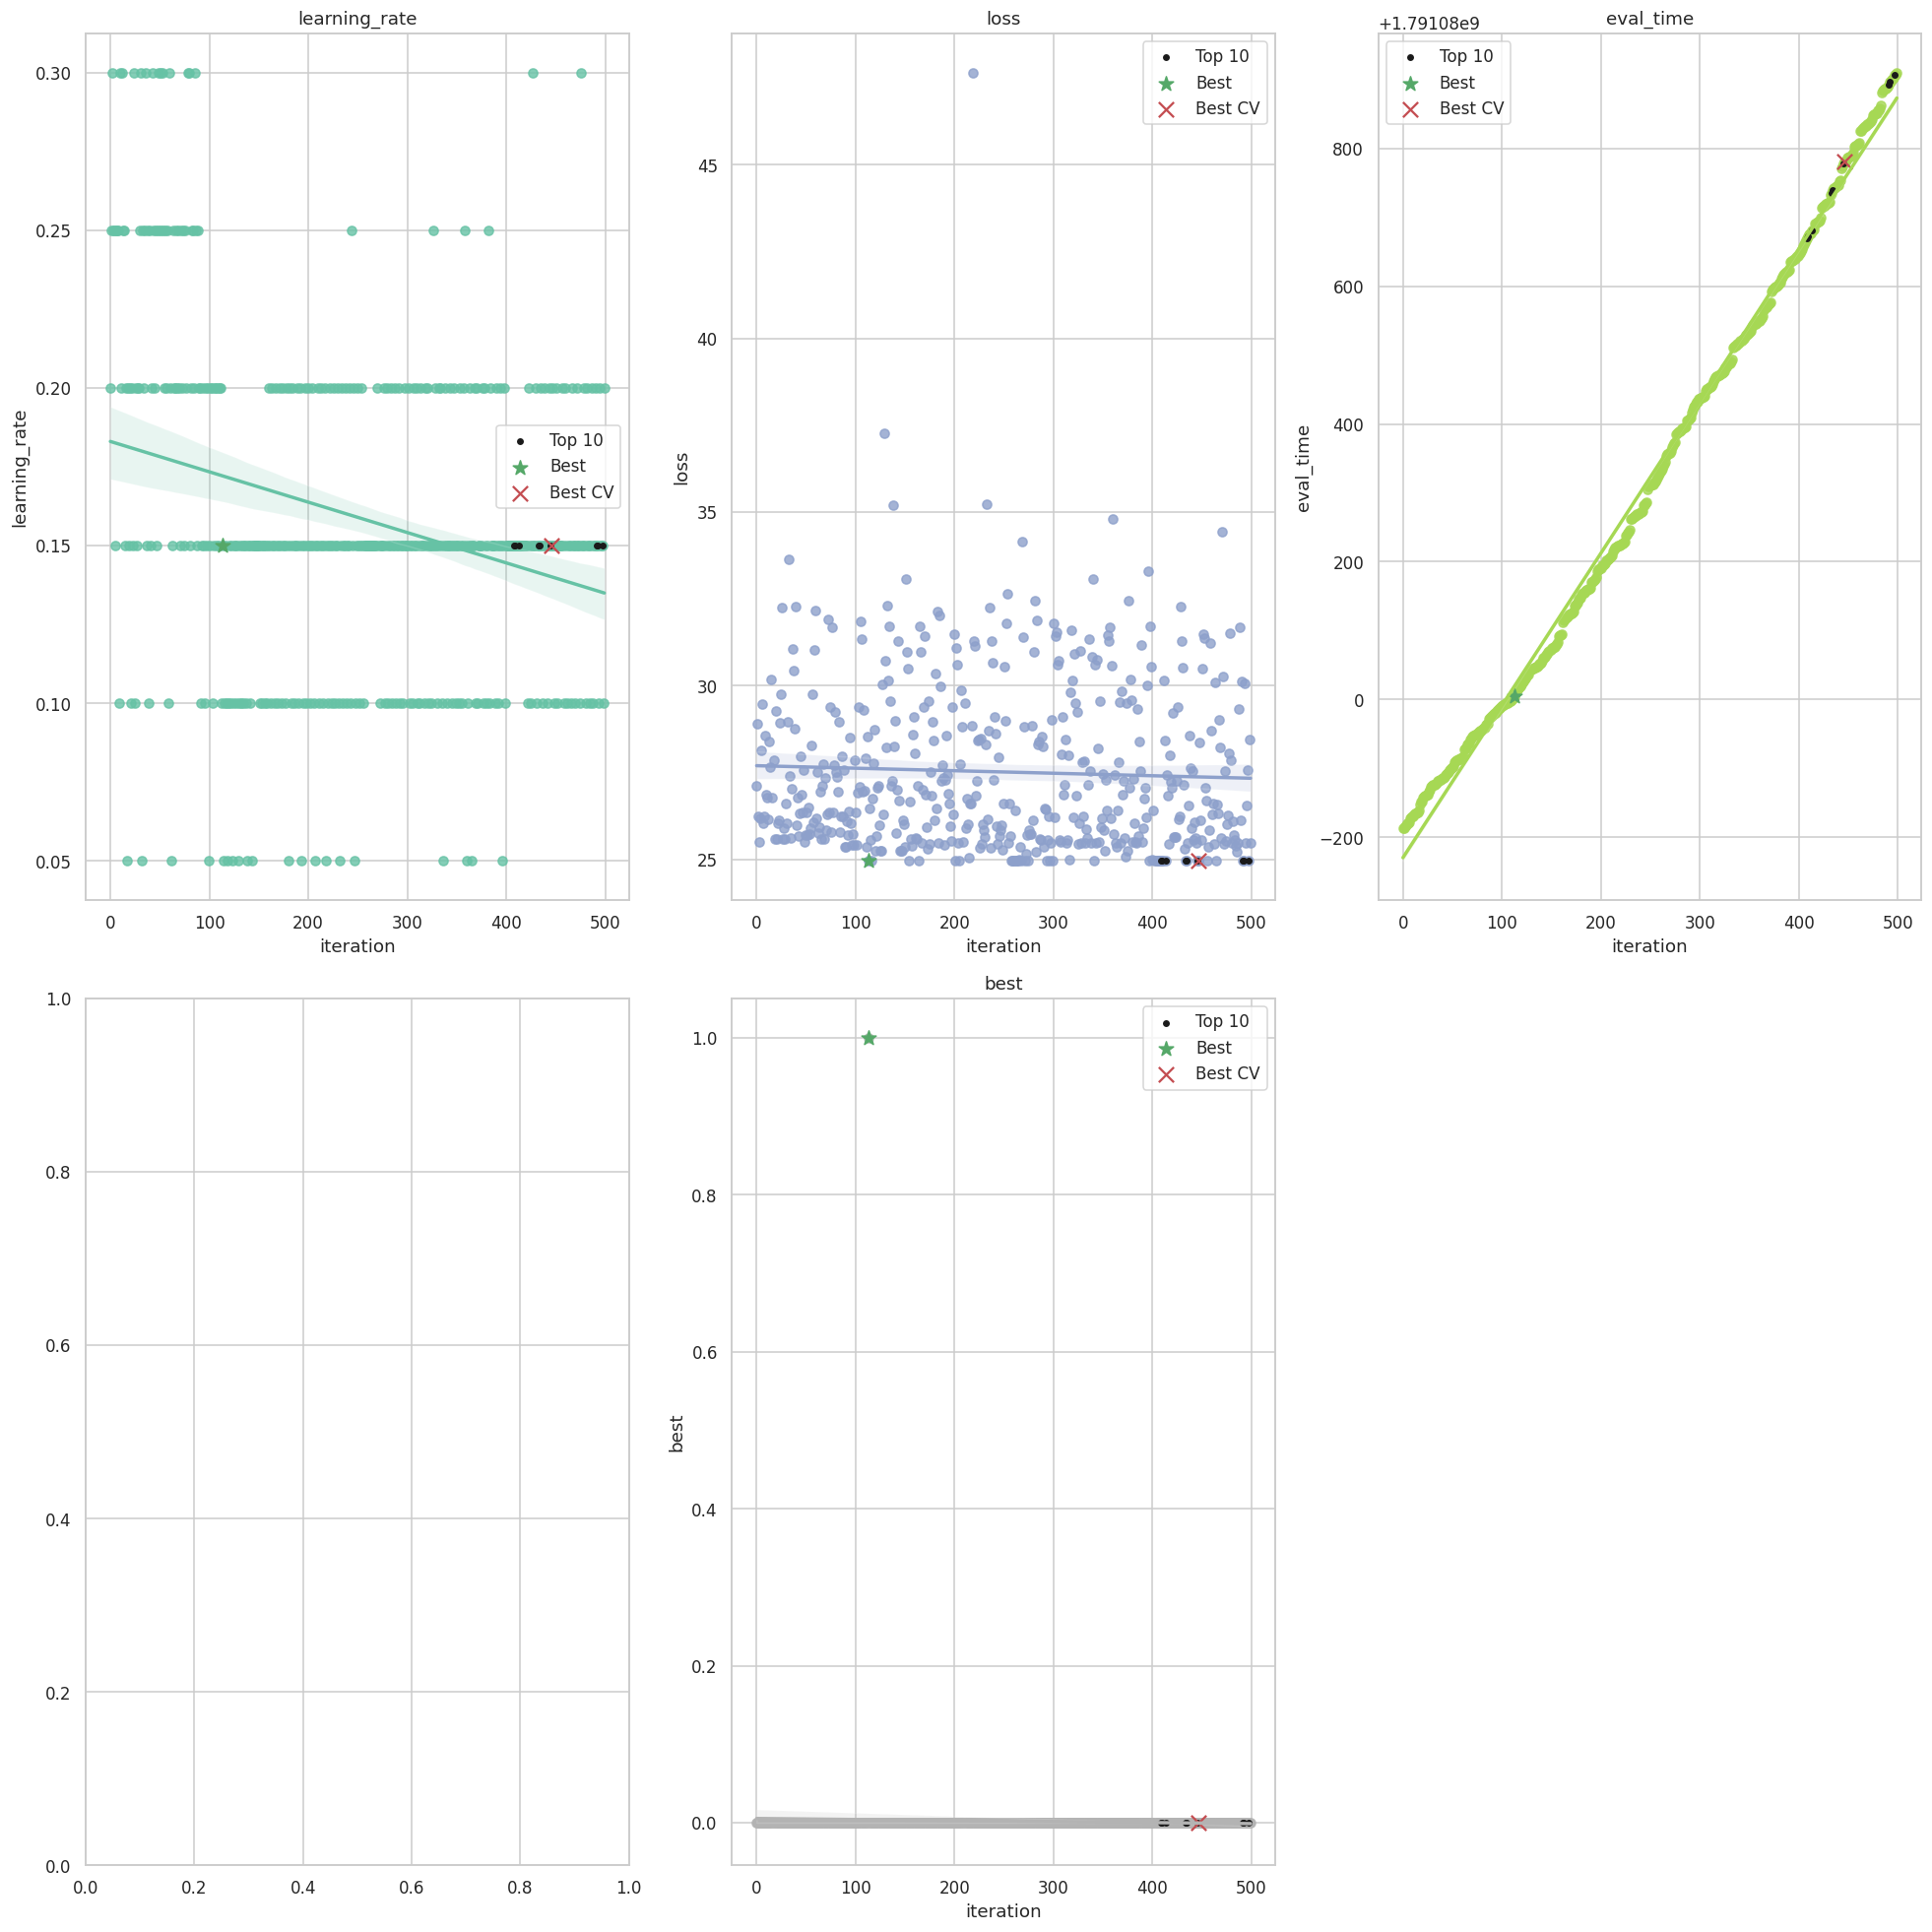

2026-10-04 02:32:01,829 5-fold crossvalidation is performed with [ctb_reg]
2026-10-04 02:32:01,841 No y_proba for ctb_reg
2026-10-04 02:32:01,855 No y_proba for ctb_reg
2026-10-04 02:32:01,867 No y_proba for ctb_reg
2026-10-04 02:32:01,879 No y_proba for ctb_reg
2026-10-04 02:32:01,889 No y_proba for ctb_reg


Saved /kaggle/working/output/figures/fig_18_figure.png


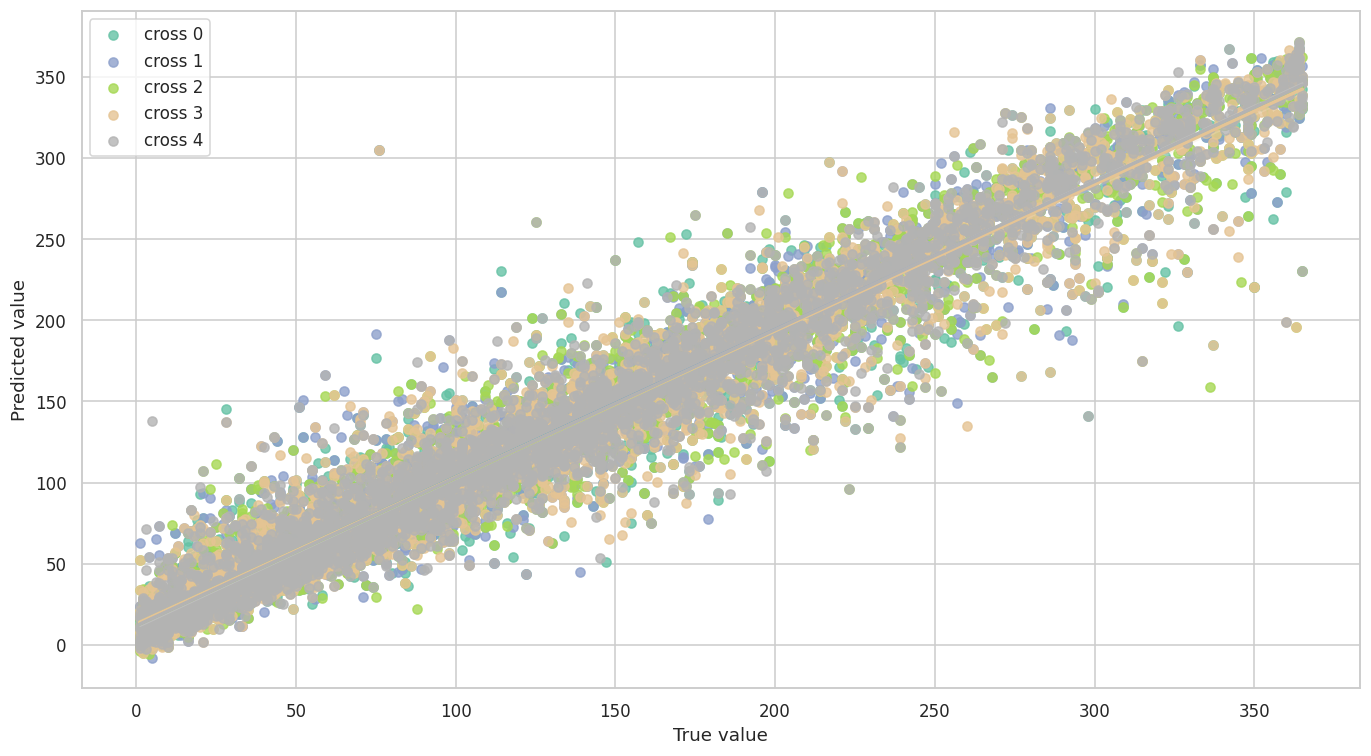

2026-10-04 02:32:04,175 No y_proba for ctb_reg


Saved /kaggle/working/output/figures/fig_19_results_on_independent_validation_set.png


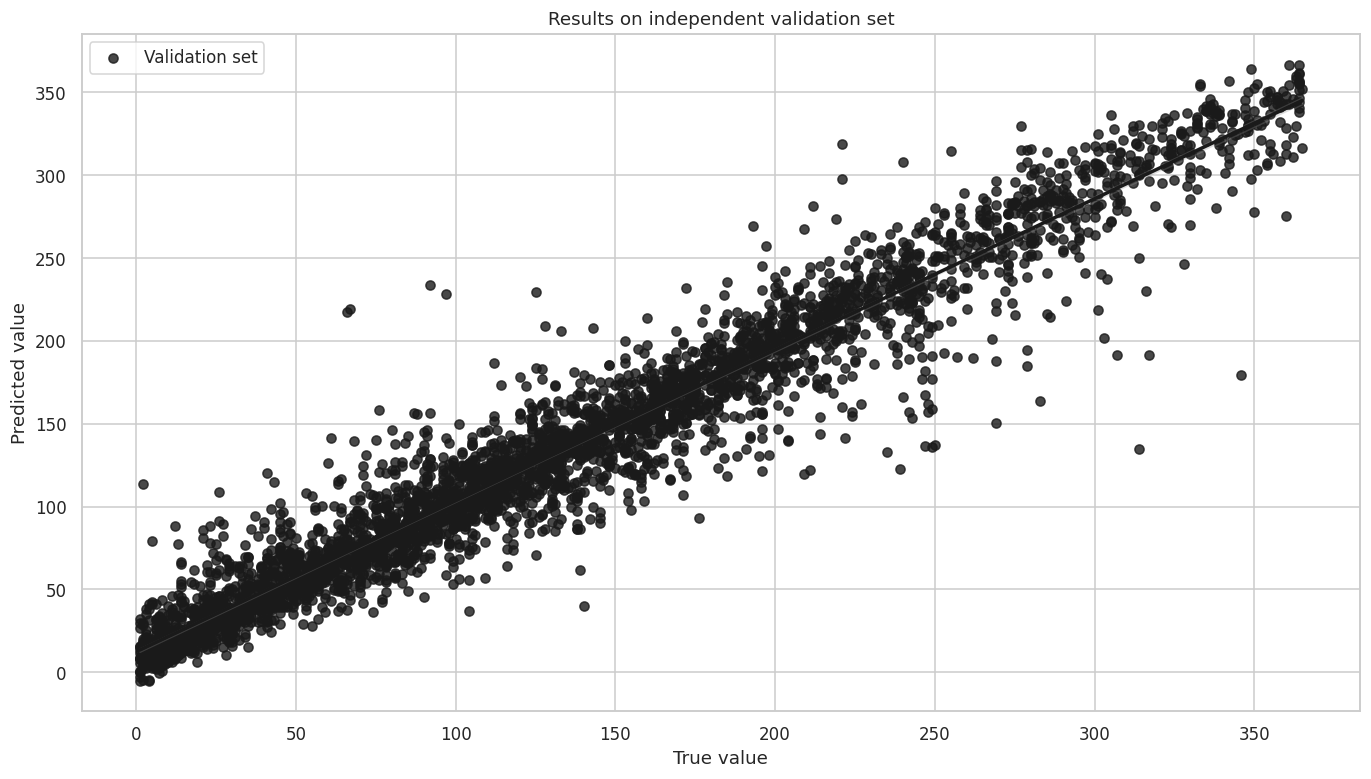

Saved /kaggle/working/output/figures/fig_20_catboost_hyperparameter_trials.png


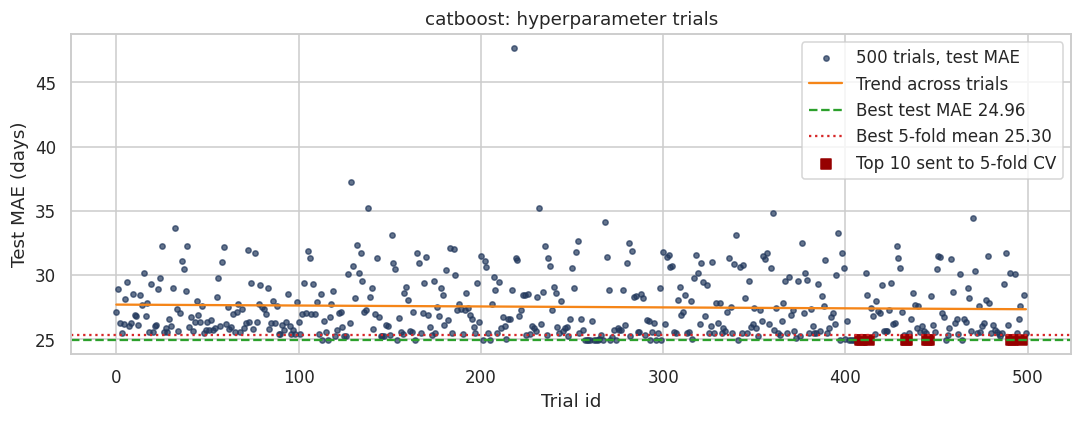

In [14]:
# cell:plots
def plot_search_curve(model, name):
    summary = model.results["summary"].copy()
    if "default_params" in summary.columns:
        summary = summary.loc[summary["default_params"].fillna(False) != True]
    summary = summary.dropna(subset=["loss"]).sort_values("tid")
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(summary["tid"], summary["loss"], s=12, color="#23395d", alpha=0.7, label=f"{len(summary)} trials, test MAE")
    if summary["loss"].notna().sum() >= 5:
        order = np.arange(len(summary))
        coeff = np.polyfit(order, summary["loss"].to_numpy(dtype=float), 1)
        ax.plot(summary["tid"], np.polyval(coeff, order), color="#f58518", label="Trend across trials")
    if "best" in summary.columns and (summary["best"] == True).any():
        best_loss = float(summary.loc[summary["best"] == True, "loss"].iloc[0])
        ax.axhline(best_loss, color="#2ca02c", ls="--", label=f"Best test MAE {best_loss:.2f}")
    if "best_cv" in summary.columns and (summary["best_cv"] == True).any():
        cv_loss = float(summary.loc[summary["best_cv"] == True, "loss_mean"].iloc[0])
        ax.axhline(cv_loss, color="#d62728", ls=":", label=f"Best 5-fold mean {cv_loss:.2f}")
    top = summary.dropna(subset=["loss_mean"])
    if len(top):
        ax.scatter(top["tid"], top["loss"], s=36, marker="s", color="#960000", label="Top 10 sent to 5-fold CV")
    ax.set_xlabel("Trial id")
    ax.set_ylabel("Test MAE (days)")
    ax.set_title(f"{name}: hyperparameter trials")
    ax.legend()
    fig.tight_layout()
    plt.show()


def show_library_plots(model, name):
    drawings = [
        ("plot", model.plot),
        ("plot_params", model.plot_params),
        ("plot_cv", model.plot_cv),
    ]
    if hasattr(model, "X_val"):
        drawings.append(("plot_validation", model.plot_validation))
    for title, function in drawings:
        try:
            function()
            plt.show()
        except Exception as exc:
            print(f"{name}.{title}() failed: {exc}")
            print("The trial curve below uses the same summary table.")


for name, model in trained.items():
    print("=" * 72)
    print(name)
    show_library_plots(model, name)
    plot_search_curve(model, name)


## 9. What the model uses

Importance is how often, or how much, a feature is used to split. SHAP is how many days that feature adds or subtracts on one row. Both are from the refit model on the development set.

Residual = predicted lead time − actual lead time. Positive means the prediction is slow. The supplier chart keeps validation suppliers with at least 5 rows, then the 15 with the most rows.

Inputs are order-time fields and past receipts. A shutdown, a missed sailing, or a failed inspection is invisible unless it already changed that supplier's historical median. A new supplier-item pair uses the coarser fallback and usually has a larger error.


### Residual, suppliers, importance, SHAP

A residual histogram centered on 0 has no overall early/late bias. Mass to the right of 0 means predicted dates run late.

Supplier bars are MAE, not a label error. A high bar means that supplier's lead time moves around.

History median and history count should be near the top of the importance chart. A receipt-only column there is leakage. Remove it and retrain.

SHAP: a point to the right of center increases predicted days. Color is the feature value. If SHAP cannot explain the GPU model, the importance bar chart is the fallback.


Saved /kaggle/working/output/figures/fig_21_validation_residual_xgboost_after_refit_median_0_1_days.png


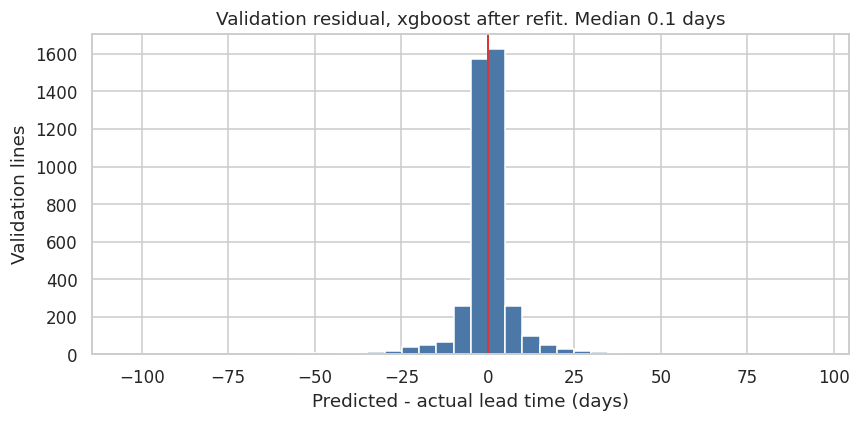

Saved /kaggle/working/output/figures/fig_22_validation_mae_for_the_15_suppliers_with_the_most_rows.png


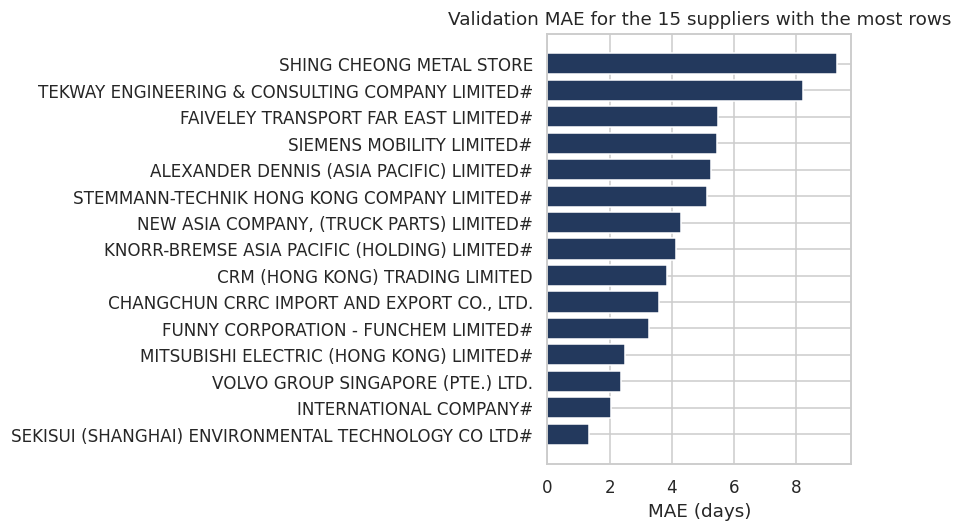

Saved /kaggle/working/output/figures/fig_23_xgboost_top_20_features.png


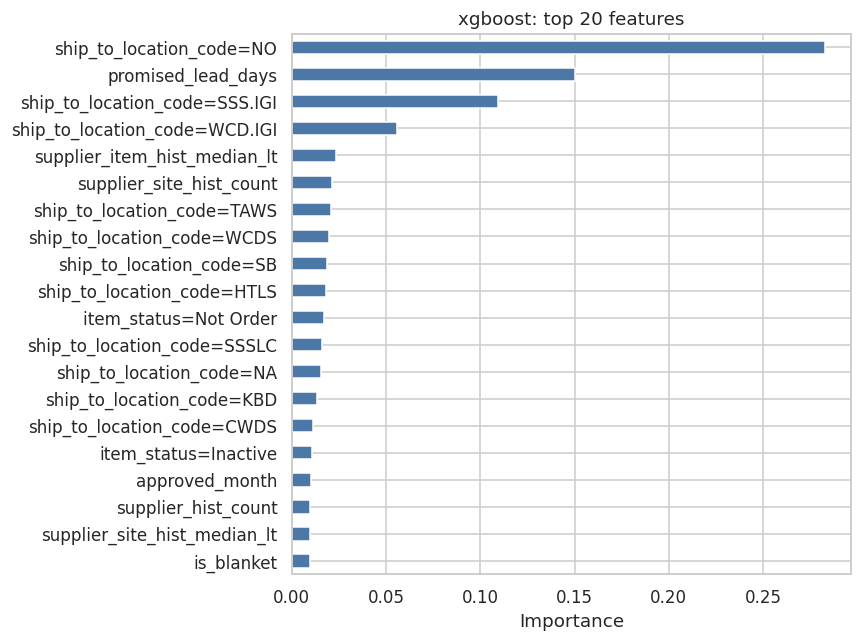

Saved /kaggle/working/output/figures/fig_24_xgboost_shap_positive_values_increase_predicted_days.png


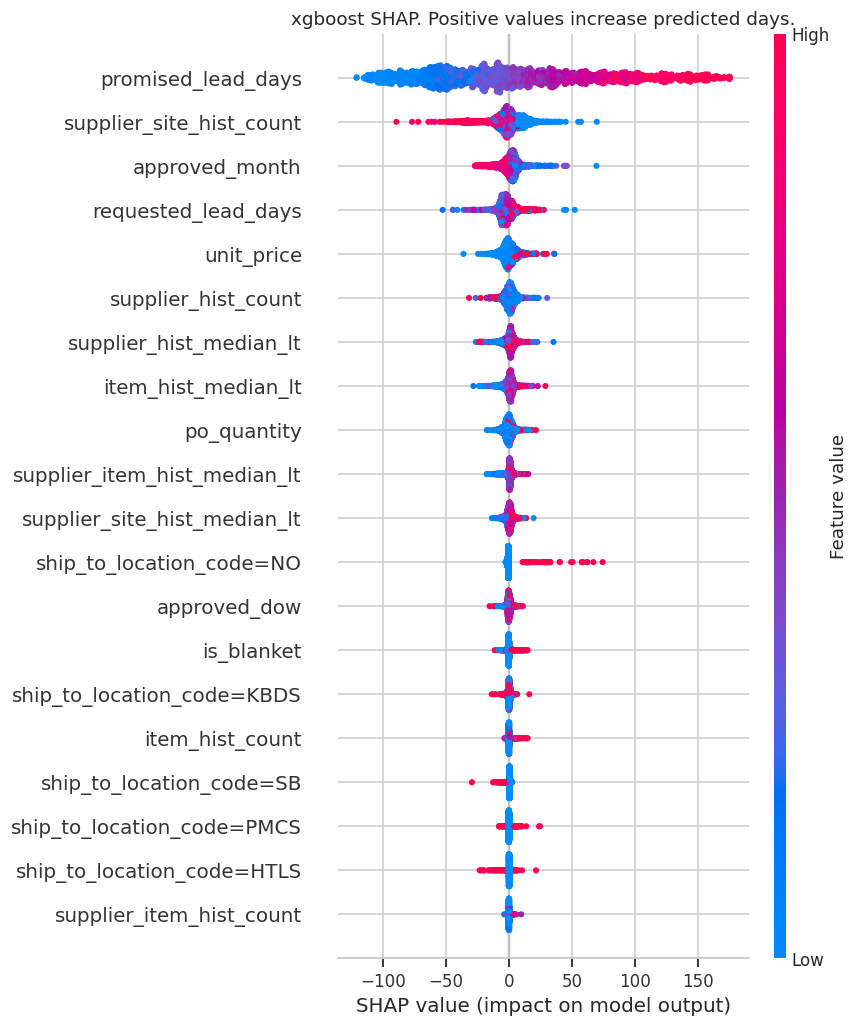

In [15]:
# cell:explain
residual = val_pred - val_actual
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residual, bins=40, color="#4c78a8", edgecolor="white")
ax.axvline(0, color="#d62728", lw=1.2)
ax.set_xlabel("Predicted - actual lead time (days)")
ax.set_ylabel("Validation lines")
ax.set_title(f"Validation residual, {winner_name} after refit. Median {np.median(residual):.1f} days")
fig.tight_layout()
plt.show()

val_suppliers = development.iloc[val_idx][["supplier"]].copy()
val_suppliers["abs_error"] = np.abs(residual)
supplier_error = (
    val_suppliers.groupby("supplier")
    .agg(rows=("abs_error", "size"), mae=("abs_error", "mean"))
    .query("rows >= 5")
    .sort_values("rows", ascending=False)
    .head(15)
    .sort_values("mae")
)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(supplier_error.index.astype(str), supplier_error["mae"], color="#23395d")
ax.set_xlabel("MAE (days)")
ax.set_title("Validation MAE for the 15 suppliers with the most rows")
fig.tight_layout()
plt.show()

importances = pd.Series(winner.model.feature_importances_, index=X_dev.columns).sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(8, 6))
importances.sort_values().plot.barh(ax=ax, color="#4c78a8")
ax.set_xlabel("Importance")
ax.set_title(f"{winner_name}: top 20 features")
fig.tight_layout()
plt.show()

try:
    import shap
    sample = X_dev.sample(n=min(2000, len(X_dev)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(winner.model)
    shap_values = explainer.shap_values(sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    shap.summary_plot(shap_values, sample, show=False)
    plt.title(f"{winner_name} SHAP. Positive values increase predicted days.")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"SHAP failed: {exc}")
    print("The importance bar chart still shows which columns the model uses.")


## 4-week backtest

These lines were approved before the cutoff and received after it. Features still use only receipts before approval. The score uses the refit model. These rows were not in the refit.

This table is the holdout result. Compare it with the historical-median baseline. Prefer the model only if its MAE is lower and its 7-day hit rate is higher.

Predicted receipt date = start date + predicted days. Detail file: `/kaggle/working/output/backtest_4w.csv`.


### Backtest charts

Row 1 of the table is the selected model. Row 2 is the historical median. MAE and MedianAE are in days. `Within_7_days` is a fraction.

A tall week on the bar chart is a receipt-week problem first, not a reason to change hyperparameters. On the date scatter, the diagonal is an exact receipt date. Points above it are late predictions.

The holdout residual uses the same sign as the validation residual. Median residual near 0 means no overall early/late bias on these 28 days.


2026-10-04 02:32:19,153 No y_proba for xgb_reg


Backtest from 2022-10-29: 702 rows.


,MAE,RMSE,R2,MedianAE,Within_7_days
model,,,,,
xgboost,46.689,58.379,0.546,40.447,0.087
history_median_baseline,72.360,94.771,-0.197,55.500,0.091


2026-10-04 02:32:19,220 Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-10-04 02:32:19,221 Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Backtest MAE is below the historical median.
Saved /kaggle/working/output/figures/fig_25_backtest_mae_by_receipt_week.png


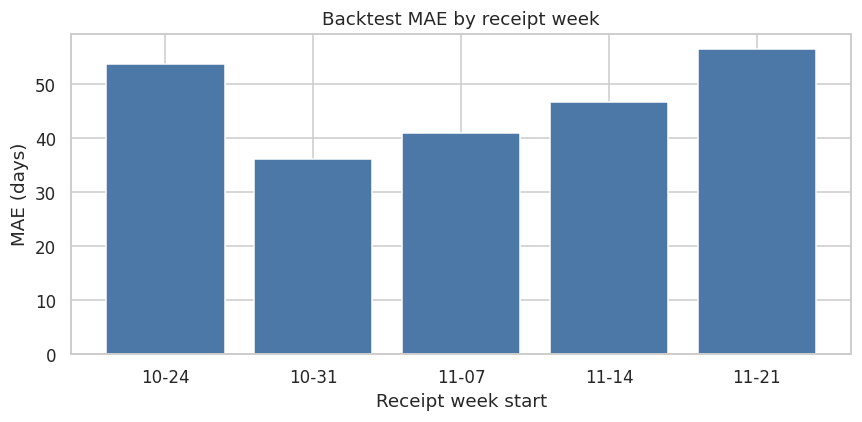

Saved /kaggle/working/output/figures/fig_26_backtest_predicted_vs_actual_receipt_date.png


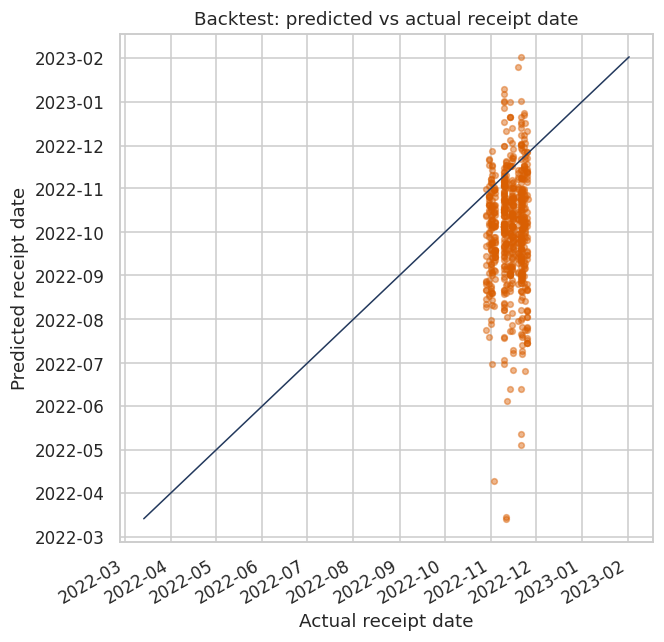

Saved /kaggle/working/output/figures/fig_27_backtest_residual_median_39_2_days.png


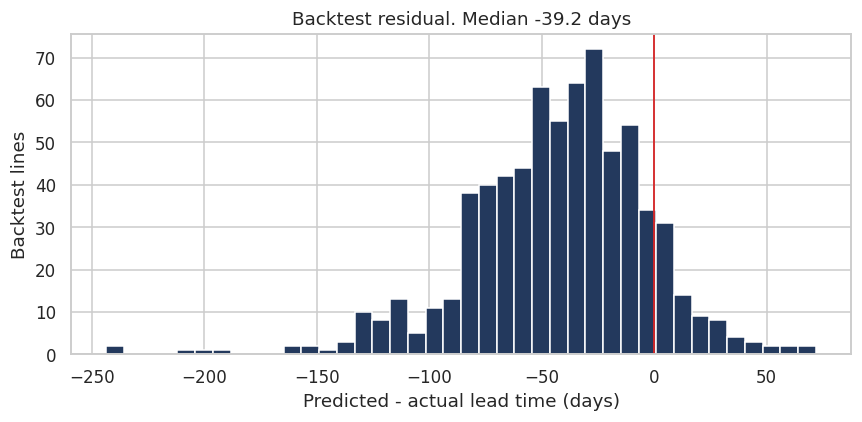

In [16]:
# cell:backtest
if len(backtest) == 0:
    print("Backtest is empty. No lines were approved before the cutoff and received inside the window.")
    backtest_metrics = pd.DataFrame()
else:
    X_backtest = build_matrix(backtest, spec)
    y_backtest = backtest["lead_time_days"].to_numpy(dtype=float)
    backtest_pred, _ = winner.predict(X_backtest)
    backtest_pred = np.asarray(backtest_pred, dtype=float).reshape(-1)
    backtest_baseline = X_backtest["supplier_item_hist_median_lt"].to_numpy(dtype=float)
    backtest_metrics = metrics_frame(
        {f"{winner_name}": backtest_pred, "history_median_baseline": backtest_baseline},
        y_backtest,
    )
    print(f"Backtest from {cutoff.date()}: {len(backtest):,} rows.")
    display(backtest_metrics.style.format("{:.3f}"))
    if backtest_metrics.loc[winner_name, "MAE"] < backtest_metrics.loc["history_median_baseline", "MAE"]:
        print("Backtest MAE is below the historical median.")
    else:
        print("Backtest MAE is not below the historical median. Keep the baseline and check leakage or a shift versus the holdout.")

    detail = backtest[["po_number", "release_num", "line_num", "line_location_id", "item_number",
                       "supplier", "start_date", "transaction_date", "lead_time_days"]].copy()
    detail["predicted_lead_time_days"] = backtest_pred
    detail["baseline_lead_time_days"] = backtest_baseline
    detail["predicted_receipt_date"] = detail["start_date"] + pd.to_timedelta(np.rint(backtest_pred), unit="D")
    detail["abs_error"] = np.abs(detail["lead_time_days"] - detail["predicted_lead_time_days"])
    detail["receipt_week"] = detail["transaction_date"].dt.to_period("W-SUN").dt.start_time
    detail.to_csv(OUTPUT_DIR / "backtest_4w.csv", index=False, encoding="utf-8-sig")

    weekly = detail.groupby("receipt_week", as_index=False).agg(rows=("abs_error", "size"), mae=("abs_error", "mean"))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(weekly["receipt_week"].dt.strftime("%m-%d"), weekly["mae"], color="#4c78a8")
    ax.set_xlabel("Receipt week start")
    ax.set_ylabel("MAE (days)")
    ax.set_title("Backtest MAE by receipt week")
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(6.2, 6))
    ax.scatter(detail["transaction_date"].dt.normalize(), detail["predicted_receipt_date"], s=14, alpha=0.45, color="#d95f02")
    start = min(detail["transaction_date"].min(), detail["predicted_receipt_date"].min())
    end = max(detail["transaction_date"].max(), detail["predicted_receipt_date"].max())
    ax.plot([start, end], [start, end], color="#23395d", lw=1)
    ax.set_xlabel("Actual receipt date")
    ax.set_ylabel("Predicted receipt date")
    ax.set_title("Backtest: predicted vs actual receipt date")
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

    bt_residual = backtest_pred - y_backtest
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(bt_residual, bins=40, color="#23395d", edgecolor="white")
    ax.axvline(0, color="#d62728", lw=1.2)
    ax.set_xlabel("Predicted - actual lead time (days)")
    ax.set_ylabel("Backtest lines")
    ax.set_title(f"Backtest residual. Median {np.median(bt_residual):.1f} days")
    fig.tight_layout()
    plt.show()


## Open POs

The local notebook scores lines that are still open. That extract is not in `cleaned_leadtime.parquet`, so there is nothing to score here. Download the winner pickle and `feature_spec.pkl` from `/kaggle/working/models` if those lines are scored later.

Predicted receipt date for an open line would still be start date + predicted days.


## Run notes

Order of work: load the cleaned parquet, prior medians, cut the last 28 days, 60/20/20 on what remains, 500 trials on the GPU, 5-fold on the top 10, lowest CV MAE wins, refit on the development set, score the holdout.

Search parameters:

- `learning_rate`: size of each new tree's correction. Searched from about 0.05 to 0.30.
- `max_depth`: more depth fits rare supplier-item cases and overfits sooner. The 5-fold step is the check.
- `n_estimators`: maximum trees. Early stopping usually stops sooner.
- `subsample`: fraction of rows per tree (XGBoost and LightGBM).
- `min_child_weight`: larger values refuse splits on small groups.
- `gamma`, `reg_lambda`: penalties on extra splits.
- CatBoost GPU: `bootstrap_type='Poisson'`. `colsample_bylevel` is not searched, because GPU CatBoost rejects it.

Hyperopt chooses the next trial from the MAE of trials already run. `MAX_EVAL` is the trial budget. One parameter set is kept per algorithm. `FAST_DEV = True` uses 10 trials per algorithm and is only a smoke test.

The test slice is used to rank trials, so its MAE is optimistic. The validation slice is not. Changing features or `MAX_EVAL` after looking at the validation score uses that slice up. After a change, read the new backtest number.

If MAE stays high:

- Many rows have no supplier-item history: those rows fall back to the supplier or global median.
- Real lead times exceed the cap: raise `LEAD_TIME_CAP_DAYS` and rerun from the filter cell. The Kaggle file was built with the 365-day cap.
- The trial curve is already flat: a larger `MAX_EVAL` usually adds little.
- Backtest MAE is not below the historical median: keep the baseline. Check for receipt fields used as inputs, and for a mix shift versus the last 28 days.

Charts, in the order they are drawn: missing-value bars, lead-time histogram, split diagram, top-10 table, algorithm bars, validation scatter, `.plot()` and the trial curve, `.plot_params()`, `.plot_cv()`, `.plot_validation()`, residual histogram, supplier MAE, importance, SHAP, backtest table, MAE by receipt week, predicted vs actual receipt date, holdout residual. PNG copies are under `/kaggle/working/output/figures`.
